In [88]:
# !pip install pandas
# !pip install matplotlib
# !pip install openpyxl
# !pip install scikit-learn
# !pip install seaborn
# !pip install statsmodels
# !pip install xgboost

In [89]:
# Initialization of packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import sklearn
import seaborn as sns
import statsmodels.api as sm
import glob
import os
import re


from xgboost import XGBClassifier

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from ModelingFunctions.GEMpythonlib.GEMpythonfunctions import *
from statsmodels.tsa.stattools import acf

from hmmlearn.hmm import GaussianHMM

In [90]:
# Define the columns and the prefixes you want to use
freq_a = 'Frequency 1C712FB8 (Hgr Katwa - Labo)'
freq_b = 'Frequency AEBA416D (Hgr Katwa - Cabine)'
volt_a = 'Voltage 1C712FB8 (Hgr Katwa - Labo)'
volt_b = 'Voltage AEBA416D (Hgr Katwa - Cabine)'


# Define the columns and the prefixes you want to use
columns_to_compare = [
    (freq_a, 'freq_lab'),
    (freq_b, 'freq_clinique'),
    (volt_a, 'volt_lab'),
    (volt_b, 'volt_clinique')
]


# Array or dataframe initialization
data = []

# Constant initialization
minutes_interval = 2

# Constants
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

# unit changes
kwh_to_hp_hr = 1.341
lb_to_gr = 453.592


# List of emissions
emissions = ['NOx', 'CO', 'SOx', 'CO2', 'PM']

# 1. Loading the Data

In [91]:
# Opening files
file_list = ['Voltage Time Series-data-2025-05-03 11_34_18.csv',  
             'Voltage Time Series-data-2025-05-03 11_38_03.csv', 
             'Voltage Time Series-data-2025-05-03 11_38_25.csv',
             'Voltage Time Series-data-2025-05-03 11_38_44.csv']

file_path = '../../data/5. Combination 5/training/katwa/'

# Initialize an empty list to collect DataFrames
data_frames = []

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path + file)
    data_frames.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

,Time,Frequency 1C712FB8 (Hgr Katwa - Labo),Frequency AEBA416D (Hgr Katwa - Cabine),Voltage 1C712FB8 (Hgr Katwa - Labo),Voltage AEBA416D (Hgr Katwa - Cabine),Generator_ON
0,1/1/23 0:00,50.0,49.9,225.0,224.0,False
1,1/1/23 0:02,49.7,49.9,225.0,224.0,False
2,1/1/23 0:04,50.1,49.8,226.0,223.0,False
3,1/1/23 0:06,50.2,49.9,226.0,224.0,False
4,1/1/23 0:08,49.7,50.0,226.0,223.0,False
...,...,...,...,...,...,...
20155,1/28/23 23:50,50.0,50.0,220.0,221.0,False
20156,1/28/23 23:52,49.8,49.8,220.0,220.0,False
20157,1/28/23 23:54,49.9,49.9,220.0,221.0,False
20158,1/28/23 23:56,50.0,50.0,221.0,221.0,False


In [92]:
# Sort values by 'Time' in ascending order
data.sort_values('Time', ascending=True, inplace=True)

# Now you can proceed to drop the duplicates as before
data.drop_duplicates(subset='Time', inplace=True)

# Reset the index after dropping duplicates
data.reset_index(drop=True, inplace=True)

# Display the cleaned data
display(data)

,Time,Frequency 1C712FB8 (Hgr Katwa - Labo),Frequency AEBA416D (Hgr Katwa - Cabine),Voltage 1C712FB8 (Hgr Katwa - Labo),Voltage AEBA416D (Hgr Katwa - Cabine),Generator_ON
0,1/1/23 0:00,50.0,49.9,225.0,224.0,False
1,1/1/23 0:02,49.7,49.9,225.0,224.0,False
2,1/1/23 0:04,50.1,49.8,226.0,223.0,False
3,1/1/23 0:06,50.2,49.9,226.0,224.0,False
4,1/1/23 0:08,49.7,50.0,226.0,223.0,False
...,...,...,...,...,...,...
20155,1/9/23 9:50,50.2,50.3,206.0,209.0,False
20156,1/9/23 9:52,49.9,49.9,207.0,204.0,False
20157,1/9/23 9:54,49.9,49.8,208.0,204.0,False
20158,1/9/23 9:56,50.2,50.2,211.0,204.0,False


In [93]:
# Checking if all rows have the same date time format:

data['Time'] = pd.to_datetime(data['Time'], format="%m/%d/%y %H:%M")
data['Time'].dtype

dtype('<M8[ns]')

In [94]:
# Check interval of data:

is_valid, invalid_data = check_time_intervals(data)

# If there are invalid rows, display them
if not is_valid:
    print("Invalid rows:")
    display(invalid_data)
    
#display(data.iloc[10078:10082])

Some rows are not separated by exactly 2 minutes.
Invalid rows:


,Time,Frequency 1C712FB8 (Hgr Katwa - Labo),Frequency AEBA416D (Hgr Katwa - Cabine),Voltage 1C712FB8 (Hgr Katwa - Labo),Voltage AEBA416D (Hgr Katwa - Cabine),Generator_ON,time_diff
0,2023-01-01,50.0,49.9,225.0,224.0,False,NaT


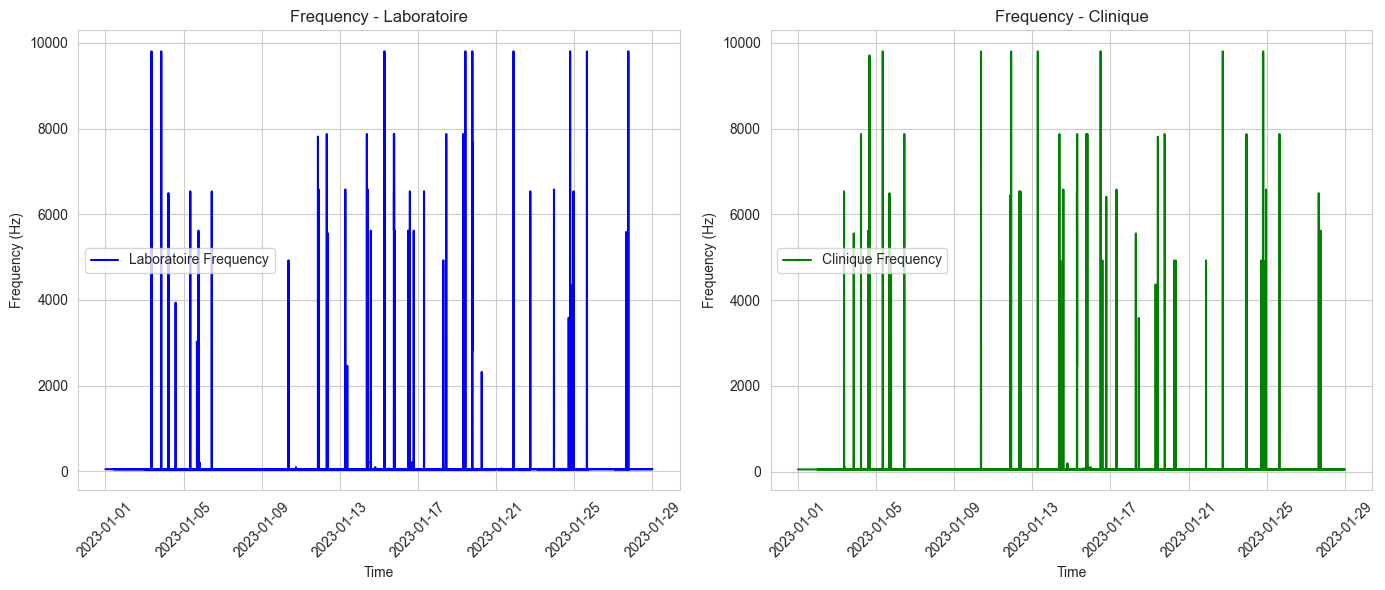

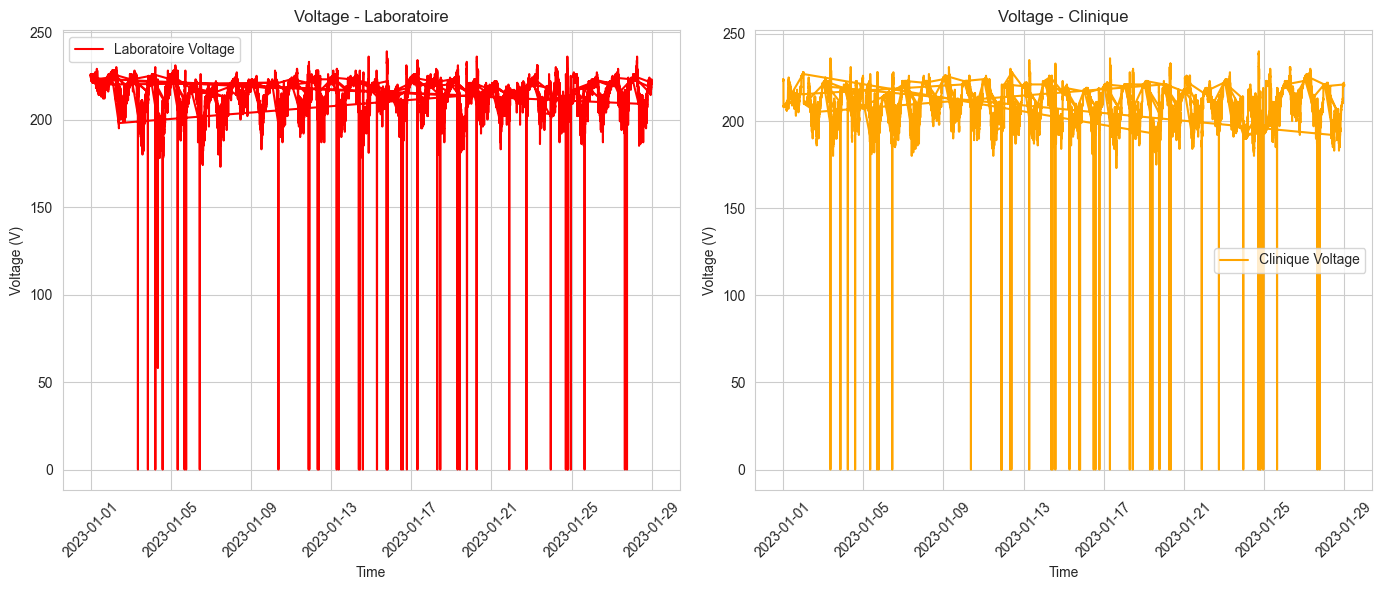

In [95]:
# Convert 'Time' column to datetime format
data['Time'] = pd.to_datetime(data['Time'])

# Plot Frequency for both facilities
plt.figure(figsize=(14, 6))

# Plot Frequency for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data[freq_a], label='Laboratoire Frequency', color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Frequency for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data[freq_b], label='Clinique Frequency', color='green')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# Plot Voltage for both facilities
plt.figure(figsize=(14, 6))

# Plot Voltage for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data[volt_a], label='Laboratoire Voltage', color='red')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Voltage for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data[volt_b], label='Clinique Voltage', color='orange')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [96]:
# List of columns to calculate statistics
columns_of_interest = [
    freq_a,
    freq_b,
    volt_a,
    volt_b
]

# Calculate the statistics for each column, including mean, median, percentiles, and null counts
stats = data[columns_of_interest].agg([
    'mean',
    'median',
    lambda x: x.quantile(0.01),  # 1st percentile
    lambda x: x.quantile(0.99),  # 99th percentile
    lambda x: x.isnull().sum()/x.sum()*100  # Null counts
])

# Renaming the lambda output columns
stats.columns = columns_of_interest
stats.index = ['Mean', 'Median', '1st Percentile', '99th Percentile', 'Null Count (%)']

# Display the statistics
print(stats)

                 Frequency 1C712FB8 (Hgr Katwa - Labo)  \
Mean                                         82.076072   
Median                                       50.000000   
1st Percentile                               49.300000   
99th Percentile                              54.800000   
Null Count (%)                                0.000968   

                 Frequency AEBA416D (Hgr Katwa - Cabine)  \
Mean                                           82.320897   
Median                                         50.000000   
1st Percentile                                 49.400000   
99th Percentile                                54.700000   
Null Count (%)                                  0.000241   

                 Voltage 1C712FB8 (Hgr Katwa - Labo)  \
Mean                                      212.947766   
Median                                    216.000000   
1st Percentile                            185.000000   
99th Percentile                           228.000000   
Null Count

# 2. Training and Test Data Separation

In [97]:
# Determine the split index (60% for training)
split_index = int(len(data) * 0.6)

# Split the data into training and testing sets
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

# Display the sizes of the train and test sets
print(f'Training data size: {len(train_data)}')
print(f'Test data size: {len(test_data)}')

# Optionally, display the first few rows of each
print("Training Data Sample:")
display(train_data)

print("Test Data Sample:")
display(test_data)

Training data size: 12096
Test data size: 8064
Training Data Sample:


,Time,Frequency 1C712FB8 (Hgr Katwa - Labo),Frequency AEBA416D (Hgr Katwa - Cabine),Voltage 1C712FB8 (Hgr Katwa - Labo),Voltage AEBA416D (Hgr Katwa - Cabine),Generator_ON
0,2023-01-01 00:00:00,50.0,49.9,225.0,224.0,False
1,2023-01-01 00:02:00,49.7,49.9,225.0,224.0,False
2,2023-01-01 00:04:00,50.1,49.8,226.0,223.0,False
3,2023-01-01 00:06:00,50.2,49.9,226.0,224.0,False
4,2023-01-01 00:08:00,49.7,50.0,226.0,223.0,False
...,...,...,...,...,...,...
12091,2023-01-24 05:02:00,49.9,49.9,230.0,209.0,False
12092,2023-01-24 05:04:00,50.1,50.0,228.0,207.0,False
12093,2023-01-24 05:06:00,49.9,50.0,228.0,207.0,False
12094,2023-01-24 05:08:00,49.9,49.9,230.0,218.0,False


Test Data Sample:


,Time,Frequency 1C712FB8 (Hgr Katwa - Labo),Frequency AEBA416D (Hgr Katwa - Cabine),Voltage 1C712FB8 (Hgr Katwa - Labo),Voltage AEBA416D (Hgr Katwa - Cabine),Generator_ON
12096,2023-01-24 05:12:00,49.8,49.8,228.0,207.0,False
12097,2023-01-24 05:14:00,50.0,49.9,228.0,207.0,False
12098,2023-01-24 05:16:00,50.0,50.0,228.0,207.0,False
12099,2023-01-24 05:18:00,49.8,49.9,228.0,207.0,False
12100,2023-01-24 05:20:00,50.0,50.0,225.0,207.0,False
...,...,...,...,...,...,...
20155,2023-01-09 09:50:00,50.2,50.3,206.0,209.0,False
20156,2023-01-09 09:52:00,49.9,49.9,207.0,204.0,False
20157,2023-01-09 09:54:00,49.9,49.8,208.0,204.0,False
20158,2023-01-09 09:56:00,50.2,50.2,211.0,204.0,False


# 3. Voltage and Frequency Only 

#### *3.1. Baseline Model on the Voltage and Frequency only*

-> Choosing only the most from the train set

In [98]:
train_data_base = train_data.copy()
test_data_base = test_data.copy()

In [99]:
train_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5
test_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5

display('Train data for baseline:')
display(train_data_base['prediction'])

display('Test data for baseline:')
display(test_data_base['prediction'])

'Train data for baseline:'

0        False
1        False
2        False
3        False
4        False
         ...  
12091    False
12092    False
12093    False
12094    False
12095    False
Name: prediction, Length: 12096, dtype: bool

'Test data for baseline:'

12096    False
12097    False
12098    False
12099    False
12100    False
         ...  
20155    False
20156    False
20157    False
20158    False
20159    False
Name: prediction, Length: 8064, dtype: bool

Assessing the model:

In [100]:
# TRAIN DATA EVALUATION
metrics = evaluate_model_performance(train_data_base)

Accuracy of model: 0.8533399470899471
Confusion Matrix:
[[10322     0]
 [ 1774     0]]
Precision of model: 0.0
Recall of model: 0.0


In [101]:
# TEST DATA EVALUATION
metrics = evaluate_model_performance(test_data_base)

Accuracy of model: 0.8922371031746031
Confusion Matrix:
[[7195    0]
 [ 869    0]]
Precision of model: 0.0
Recall of model: 0.0


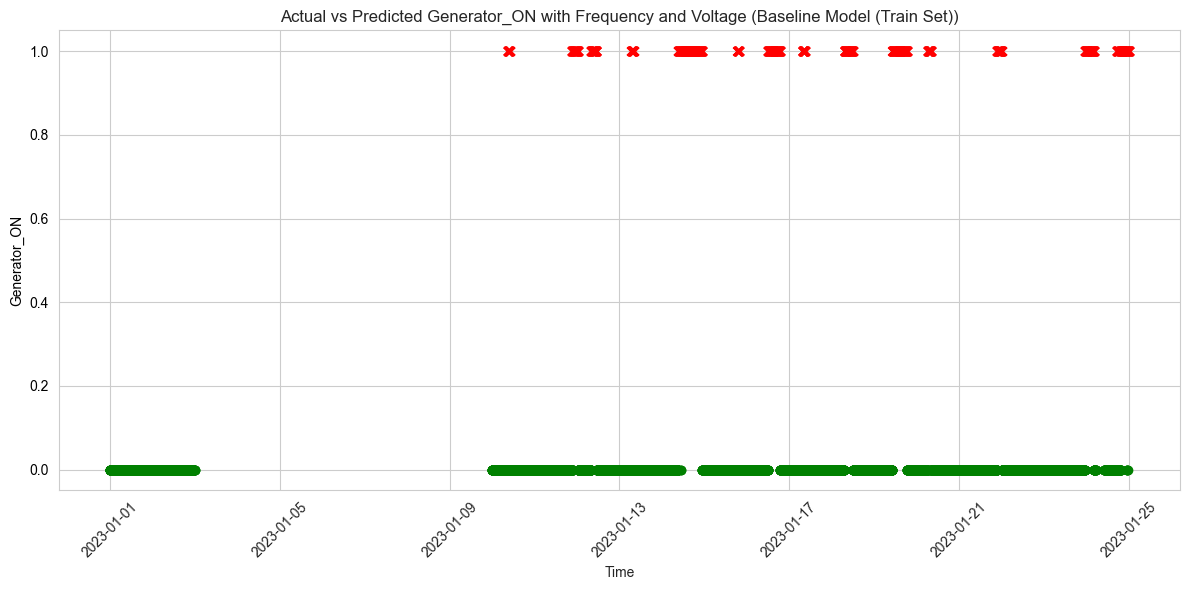

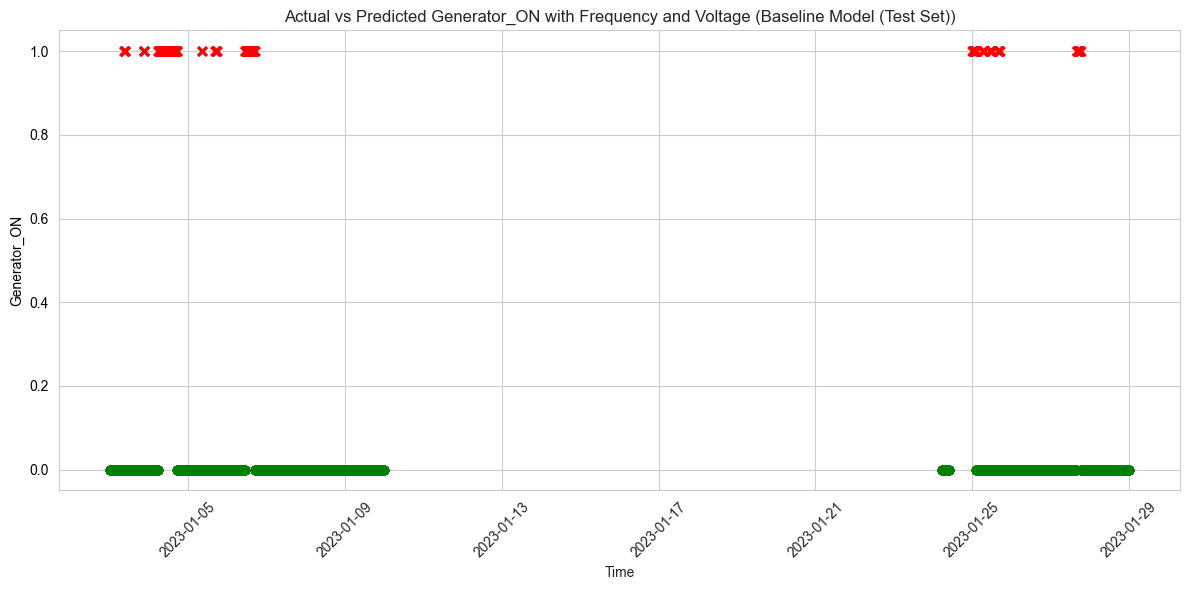

In [102]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)", 
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)",  
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

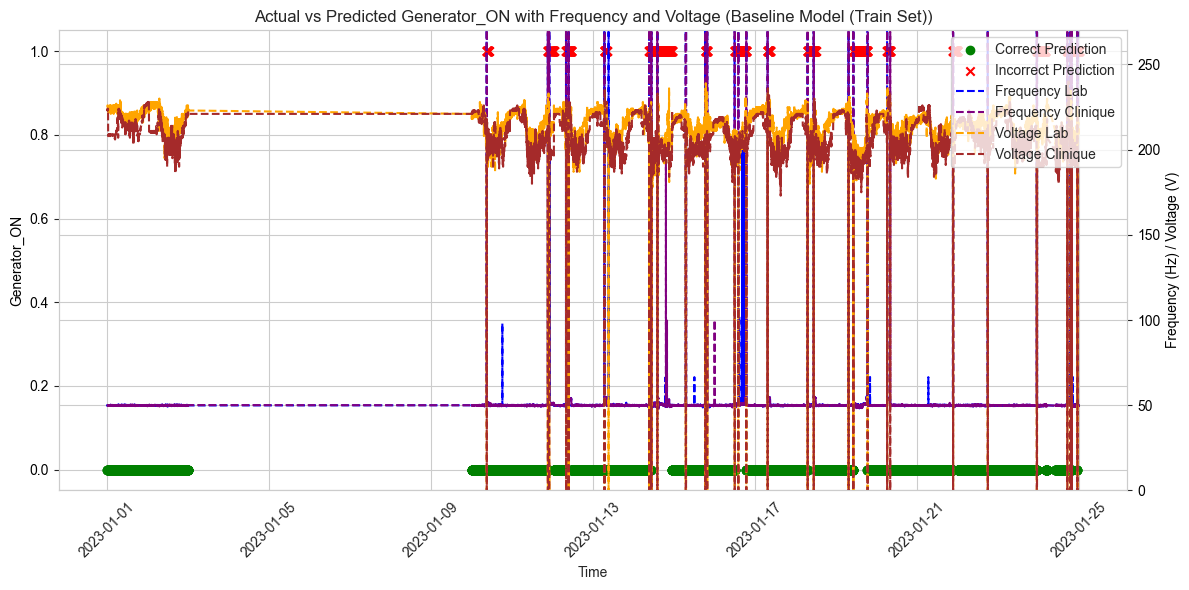

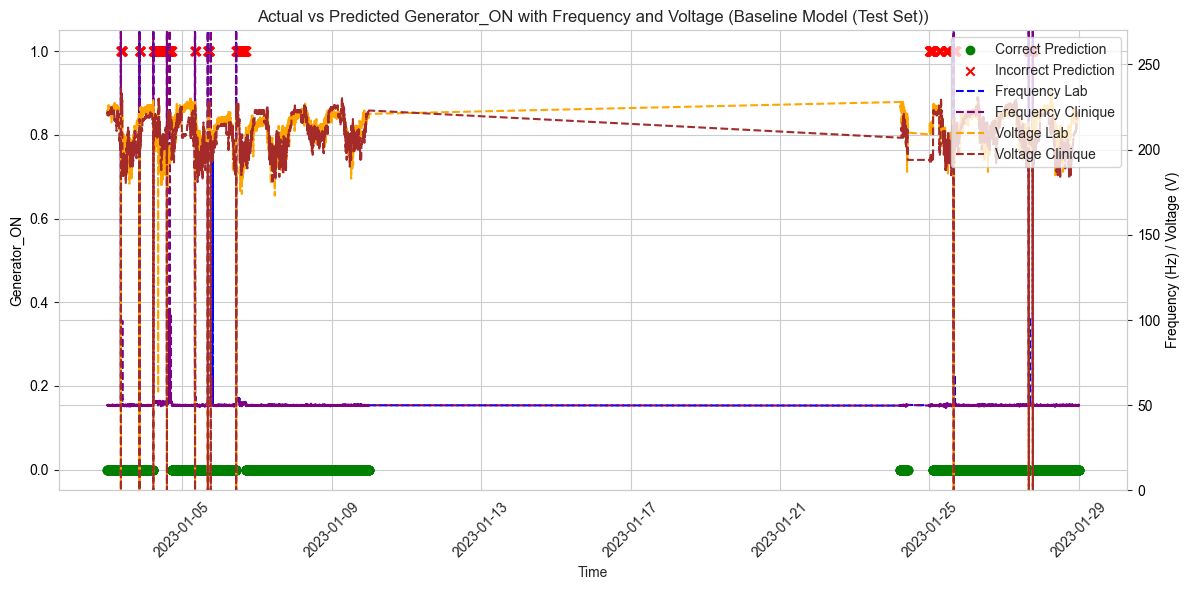

In [103]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)",  
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

#### *3.2. Logistic Regression on the Voltage and Frequency only*

In [104]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 0.85
Test Accuracy: 0.89


Evaluating the train set - Baseline Logistic Regression:

In [105]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.8517691798941799
Confusion Matrix:
[[10296    26]
 [ 1767     7]]
Precision: 0.21212121212121213
Recall: 0.003945885005636978
Train data prediction distribution:
prediction
0    12063
1       33
Name: count, dtype: int64


Evaluating the test set - Baseline Logistic Regression:

In [106]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.8919890873015873
Confusion Matrix:
[[7192    3]
 [ 868    1]]
Precision: 0.25
Recall: 0.0011507479861910242
Test data prediction distribution:
prediction
0    8060
1       4
Name: count, dtype: int64


#### *3.3. Random Forrest on the Voltage and Frequency only*

In [107]:
# Step 1: Create copies of the original data
train_data_rf = train_data.copy()
test_data_rf = test_data.copy()

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_rf[feature_columns]
y_train = train_data_rf['Generator_ON']

X_test = test_data_rf[feature_columns]
y_test = test_data_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_rf['prediction'] = clf.predict(X_train)
test_data_rf['prediction'] = clf.predict(X_test)

Evaluating the train set (Random Forrest): 

In [108]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.9918981481481481
Confusion Matrix:
[[10306    16]
 [   82  1692]]
Precision: 0.990632318501171
Recall: 0.9537767756482526
Train data prediction distribution:
prediction
False    10388
True      1708
Name: count, dtype: int64


Evaluating the test set (Random Forrest): 

In [109]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9487847222222222
Confusion Matrix:
[[6898  297]
 [ 116  753]]
Precision: 0.7171428571428572
Recall: 0.8665132336018412
Test data prediction distribution:
prediction
False    7014
True     1050
Name: count, dtype: int64


#### *3.4. XG-Boost on the Voltage and Frequency only*

Top 20 features sorted by importance (XGBoost):


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:16:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Feature,Importance
1,Frequency AEBA416D (Hgr Katwa - Cabine),0.387214
0,Frequency 1C712FB8 (Hgr Katwa - Labo),0.273554
3,Voltage AEBA416D (Hgr Katwa - Cabine),0.247882
2,Voltage 1C712FB8 (Hgr Katwa - Labo),0.091350


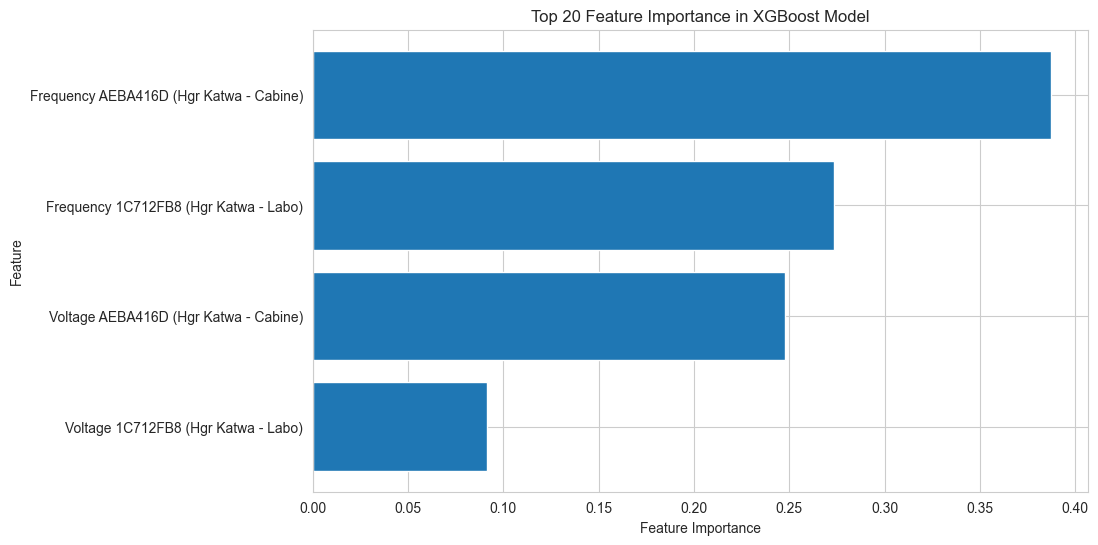

In [110]:
# Step 0: Copy rf data
train_data_boost = train_data.copy()
test_data_boost = test_data.copy()

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]


# Step 1: Use the same data and feature columns
X_train = train_data_boost[feature_columns]
y_train = train_data_boost['Generator_ON']

X_test = test_data_boost[feature_columns]
y_test = test_data_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
    use_label_encoder=False  # Avoid unnecessary warnings
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_boost['prediction'] = xgb_clf.predict(X_train)
test_data_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

In [111]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.9756944444444444
Confusion Matrix:
[[10280    42]
 [  252  1522]]
Precision: 0.9731457800511509
Recall: 0.8579481397970687
Train data prediction distribution (XGBoost):
prediction
0    10532
1     1564
Name: count, dtype: int64


In [112]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):
Accuracy: 0.9527529761904762
Confusion Matrix:
[[6932  263]
 [ 118  751]]
Precision: 0.7406311637080868
Recall: 0.8642117376294591
Test data prediction distribution (XGBoost):
prediction
0    10532
1     1564
Name: count, dtype: int64


# 4. Feature Generation

### 4.1. Using Mean as a Threshold

In [113]:
train_data_mean = train_data.copy()
test_data_mean = test_data.copy()

In [114]:
# Taking the mean of the dataframe
train_data_mean, test_data_mean = calculate_mean_flags(train_data_mean, test_data_mean, train_data_base, columns_to_compare)

# Display the updated data
display(train_data_mean)
display(test_data_mean)

,Time,Frequency 1C712FB8 (Hgr Katwa - Labo),Frequency AEBA416D (Hgr Katwa - Cabine),Voltage 1C712FB8 (Hgr Katwa - Labo),Voltage AEBA416D (Hgr Katwa - Cabine),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique
0,2023-01-01 00:00:00,50.0,49.9,225.0,224.0,False,False,False,True,True
1,2023-01-01 00:02:00,49.7,49.9,225.0,224.0,False,False,False,True,True
2,2023-01-01 00:04:00,50.1,49.8,226.0,223.0,False,False,False,True,True
3,2023-01-01 00:06:00,50.2,49.9,226.0,224.0,False,False,False,True,True
4,2023-01-01 00:08:00,49.7,50.0,226.0,223.0,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...
12091,2023-01-24 05:02:00,49.9,49.9,230.0,209.0,False,False,False,True,True
12092,2023-01-24 05:04:00,50.1,50.0,228.0,207.0,False,False,False,True,False
12093,2023-01-24 05:06:00,49.9,50.0,228.0,207.0,False,False,False,True,False
12094,2023-01-24 05:08:00,49.9,49.9,230.0,218.0,False,False,False,True,True


,Time,Frequency 1C712FB8 (Hgr Katwa - Labo),Frequency AEBA416D (Hgr Katwa - Cabine),Voltage 1C712FB8 (Hgr Katwa - Labo),Voltage AEBA416D (Hgr Katwa - Cabine),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique
12096,2023-01-24 05:12:00,49.8,49.8,228.0,207.0,False,False,False,True,False
12097,2023-01-24 05:14:00,50.0,49.9,228.0,207.0,False,False,False,True,False
12098,2023-01-24 05:16:00,50.0,50.0,228.0,207.0,False,False,False,True,False
12099,2023-01-24 05:18:00,49.8,49.9,228.0,207.0,False,False,False,True,False
12100,2023-01-24 05:20:00,50.0,50.0,225.0,207.0,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...
20155,2023-01-09 09:50:00,50.2,50.3,206.0,209.0,False,False,False,False,True
20156,2023-01-09 09:52:00,49.9,49.9,207.0,204.0,False,False,False,False,False
20157,2023-01-09 09:54:00,49.9,49.8,208.0,204.0,False,False,False,False,False
20158,2023-01-09 09:56:00,50.2,50.2,211.0,204.0,False,False,False,False,False


#### 4.1.1. Using Mean as a Threshold - Custom Prediction

In [115]:
# Define custom prediction logic
def custom_prediction(row):
    # Example: Set prediction to True if either clinic or lab has higher frequency and voltage
    if (row['higher_freq_lab'] or row['higher_volt_lab']) and (row['higher_freq_clinique'] or row['higher_volt_clinique']):
        return True
    else:
        return False

# Apply custom prediction logic
train_data_mean['prediction'] = train_data_mean.apply(custom_prediction, axis=1)
test_data_mean['prediction'] = test_data_mean.apply(custom_prediction, axis=1)

# Show prediction:
display('Train data for baseline:')
display(train_data_mean['prediction'].value_counts())

display('Test data for baseline:')
display(test_data_mean['prediction'].value_counts())

'Train data for baseline:'

prediction
True     6152
False    5944
Name: count, dtype: int64

'Test data for baseline:'

prediction
False    4075
True     3989
Name: count, dtype: int64

Assessing the mean model: 

In [116]:
metrics = evaluate_model_performance(train_data_mean)

Accuracy of model: 0.42328042328042326
Confusion Matrix:
[[4645 5677]
 [1299  475]]
Precision of model: 0.0772106631989597
Recall of model: 0.2677564825253664


In [117]:
metrics = evaluate_model_performance(test_data_mean)

Accuracy of model: 0.4337797619047619
Confusion Matrix:
[[3352 3843]
 [ 723  146]]
Precision of model: 0.03660065179242918
Recall of model: 0.16800920598388952


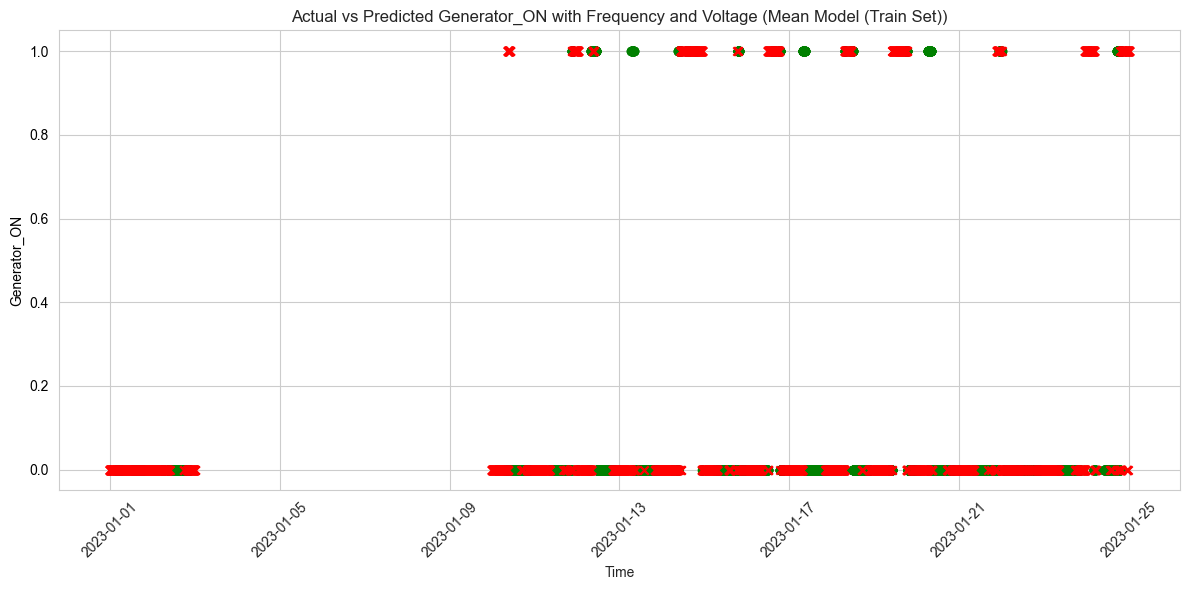

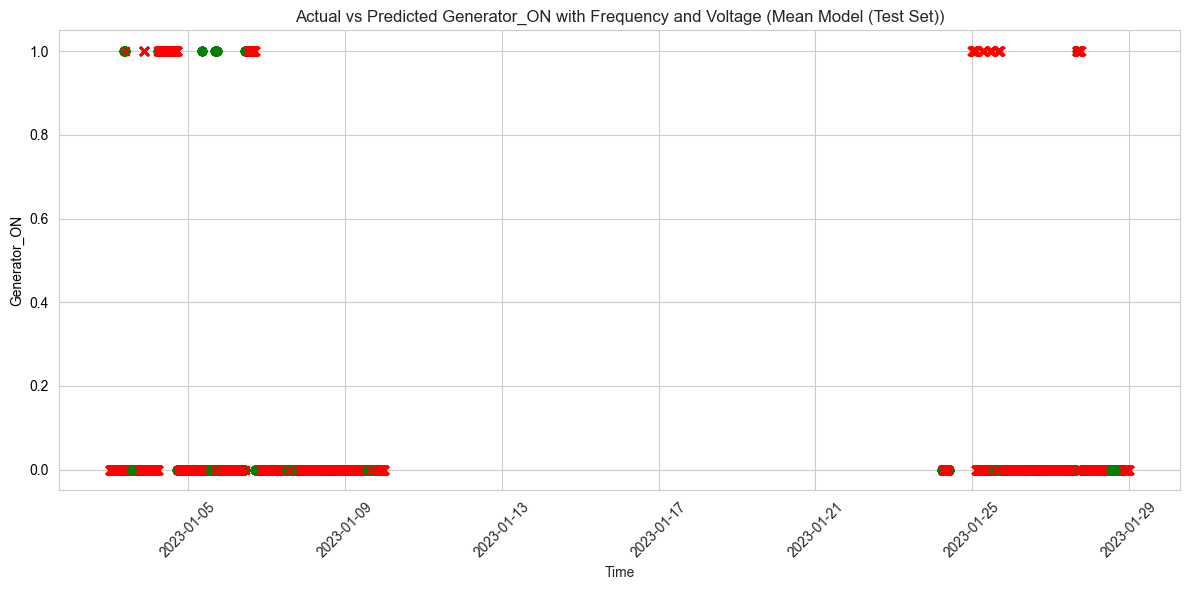

In [118]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

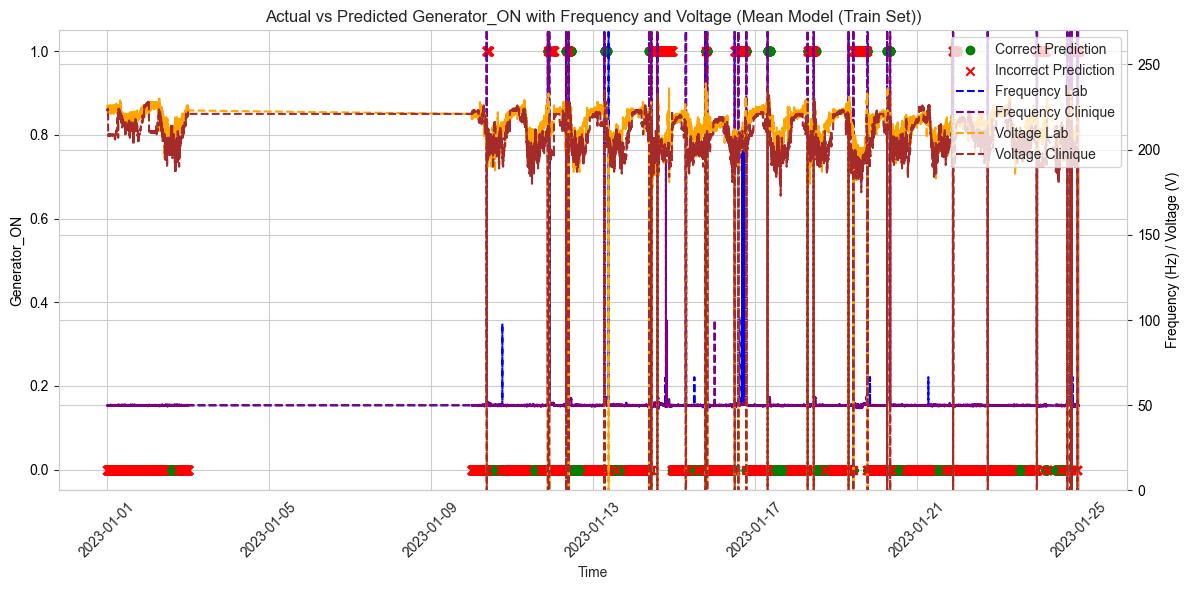

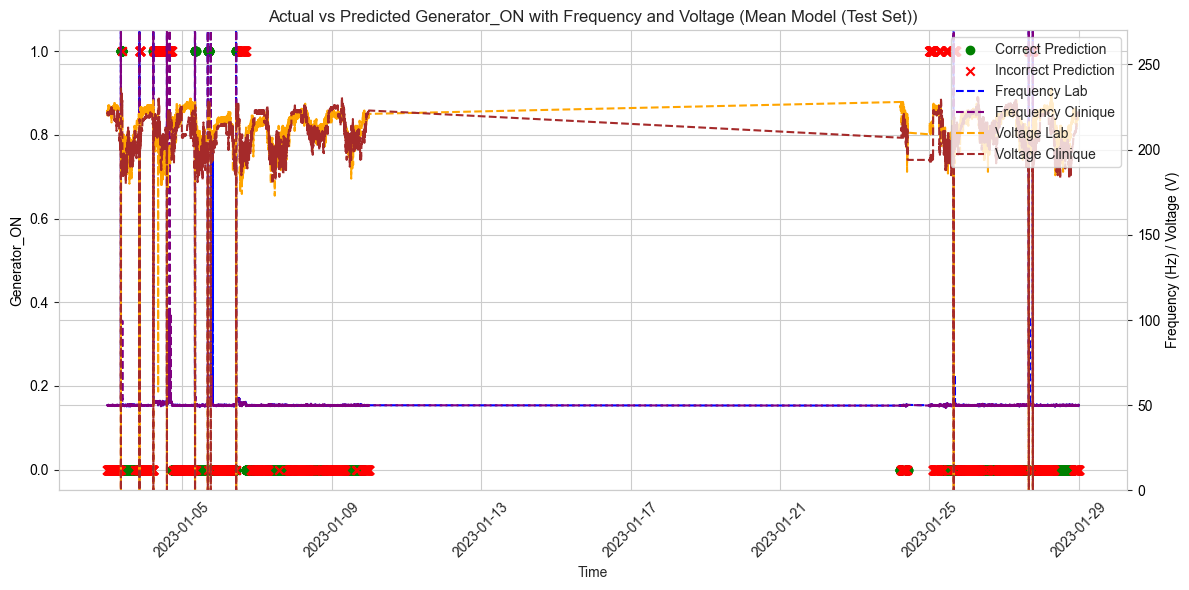

In [119]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

#### 4.1.2. Using Mean as a Threshold - Logistic Regression

In [120]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 0.86
Test Accuracy: 0.89


Evaluating the train set (Logistic Regression): 

In [121]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.8557374338624338
Confusion Matrix:
[[10318     4]
 [ 1741    33]]
Precision: 0.8918918918918919
Recall: 0.018602029312288614
Train data prediction distribution:
prediction
0    12059
1       37
Name: count, dtype: int64


Evaluating the test set (Logistic Regression): 

In [122]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.8916170634920635
Confusion Matrix:
[[7188    7]
 [ 867    2]]
Precision: 0.2222222222222222
Recall: 0.0023014959723820483
Test data prediction distribution:
prediction
0    8055
1       9
Name: count, dtype: int64


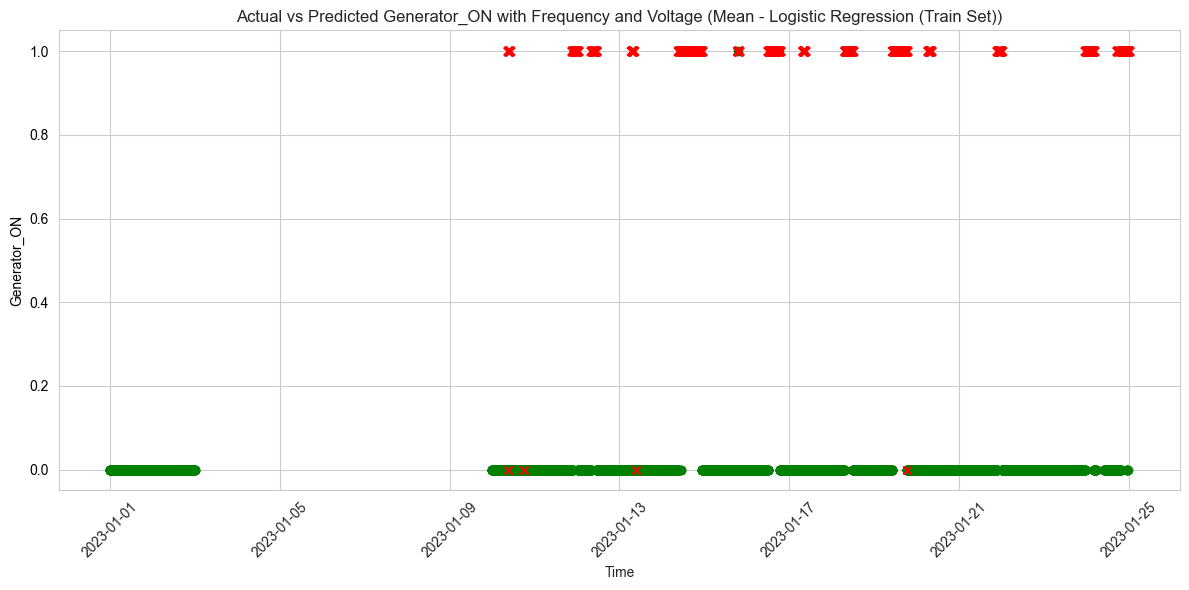

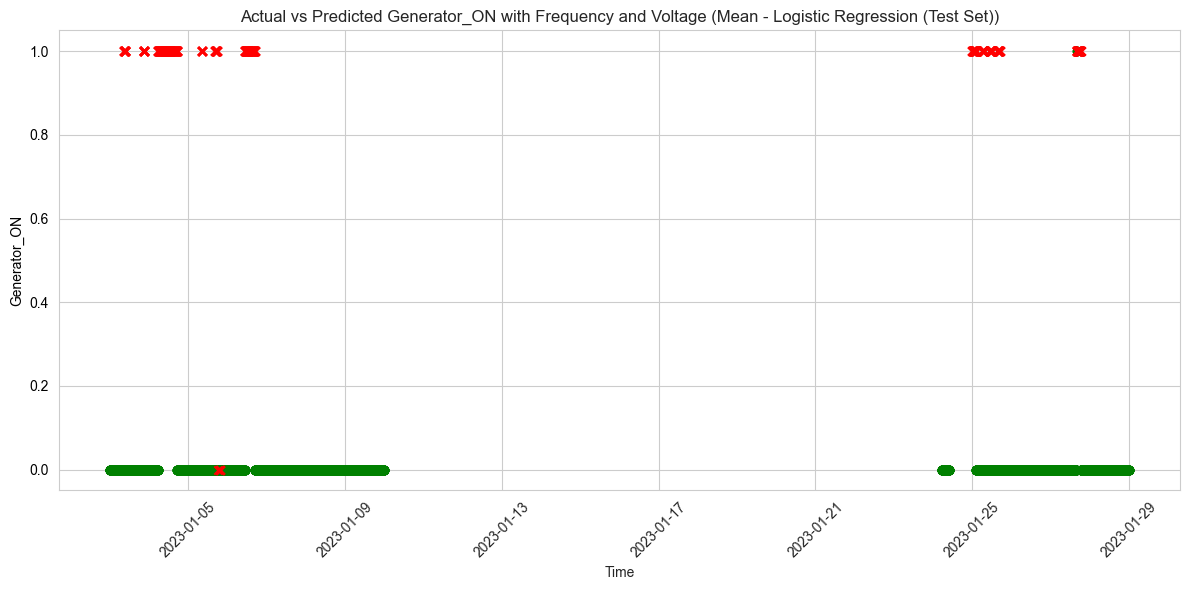

In [123]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

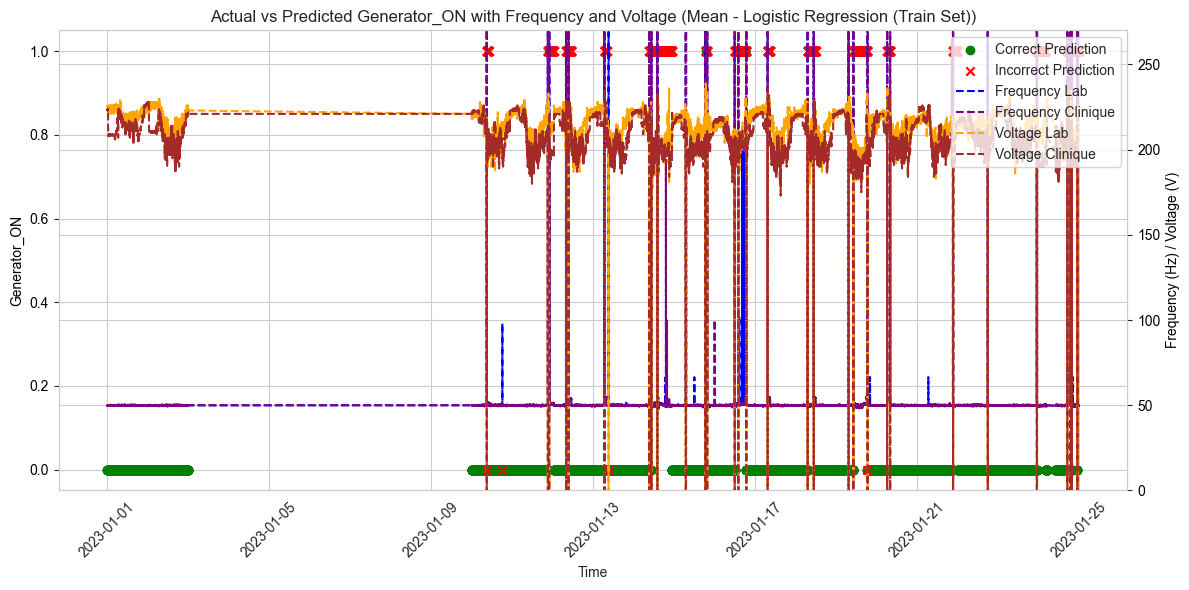

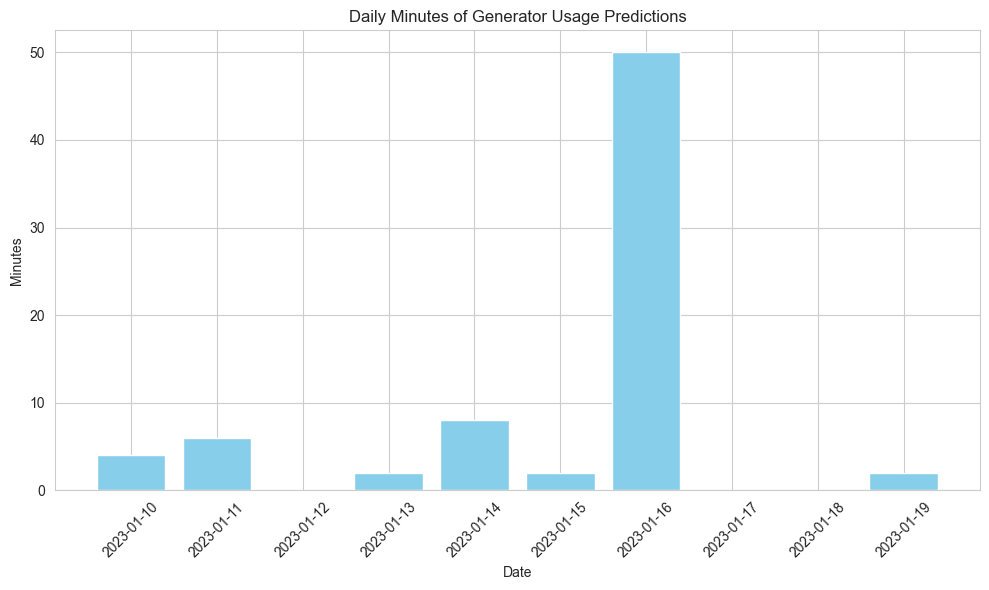

,Date,Count,Minutes,Hours
0,2023-01-10,2,4,0.066667
1,2023-01-11,3,6,0.100000
2,2023-01-13,1,2,0.033333
3,2023-01-14,4,8,0.133333
4,2023-01-15,1,2,0.033333
5,2023-01-16,25,50,0.833333
6,2023-01-19,1,2,0.033333


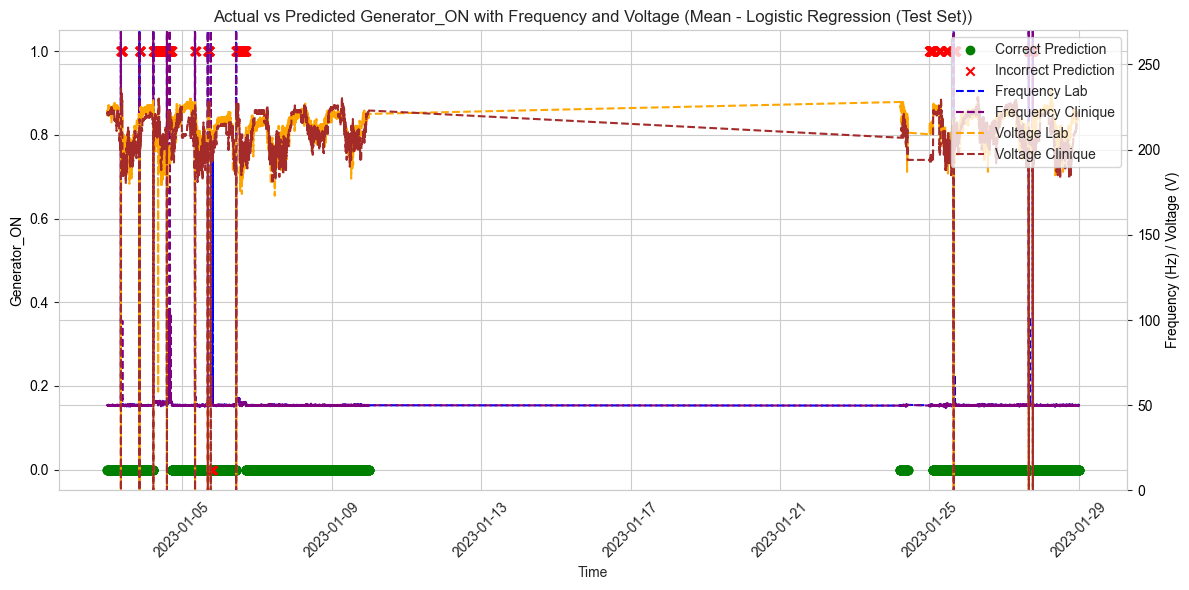

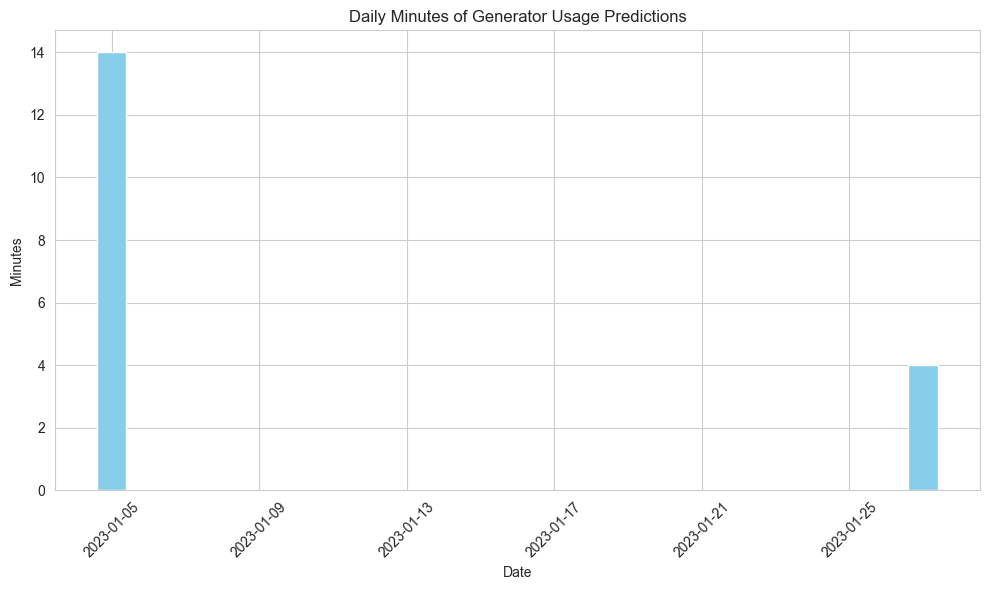

,Date,Count,Minutes,Hours
0,2023-01-05,7,14,0.233333
1,2023-01-27,2,4,0.066667


In [124]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_lg_daily_count = plot_true_predictions_histogram(train_data_mean_lg)
display(train_data_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_lg_daily_count = plot_true_predictions_histogram(test_data_mean_lg)
display(test_data_lg_daily_count)

#### 4.1.3. Using Mean as a Threshold - Random Forrest

In [125]:
# Step 1: Create copies of the original data
train_data_mean_rf = train_data.copy()
test_data_mean_rf = test_data.copy()

# Taking the mean of the dataframe
train_data_mean_rf, test_data_mean_rf = calculate_mean_flags(train_data_mean_rf, test_data_mean_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_rf[feature_columns]
y_train = train_data_mean_rf['Generator_ON']

X_test = test_data_mean_rf[feature_columns]
y_test = test_data_mean_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_rf['prediction'] = clf.predict(X_train)
test_data_mean_rf['prediction'] = clf.predict(X_test)

Evaluating the train set (Random Forrest): 

In [126]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.9918981481481481
Confusion Matrix:
[[10304    18]
 [   80  1694]]
Precision: 0.9894859813084113
Recall: 0.9549041713641488
Train data prediction distribution:
prediction
False    10384
True      1712
Name: count, dtype: int64


Evaluating the test set (Random Forrest): 

In [127]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9485367063492064
Confusion Matrix:
[[6906  289]
 [ 126  743]]
Precision: 0.7199612403100775
Recall: 0.8550057537399309
Test data prediction distribution:
prediction
False    7032
True     1032
Name: count, dtype: int64


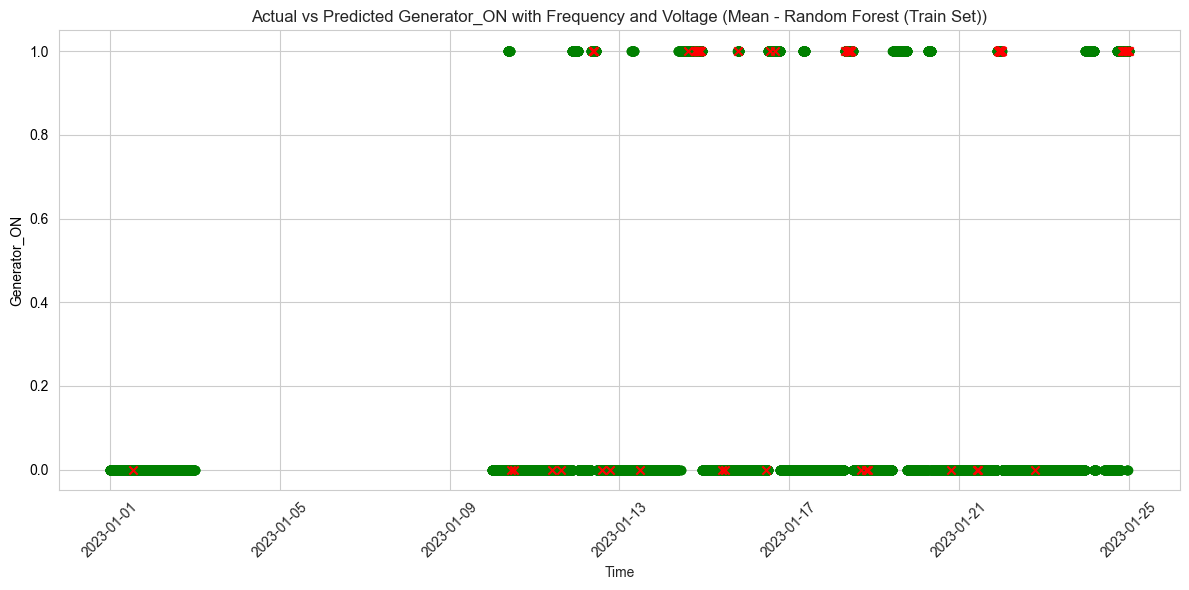

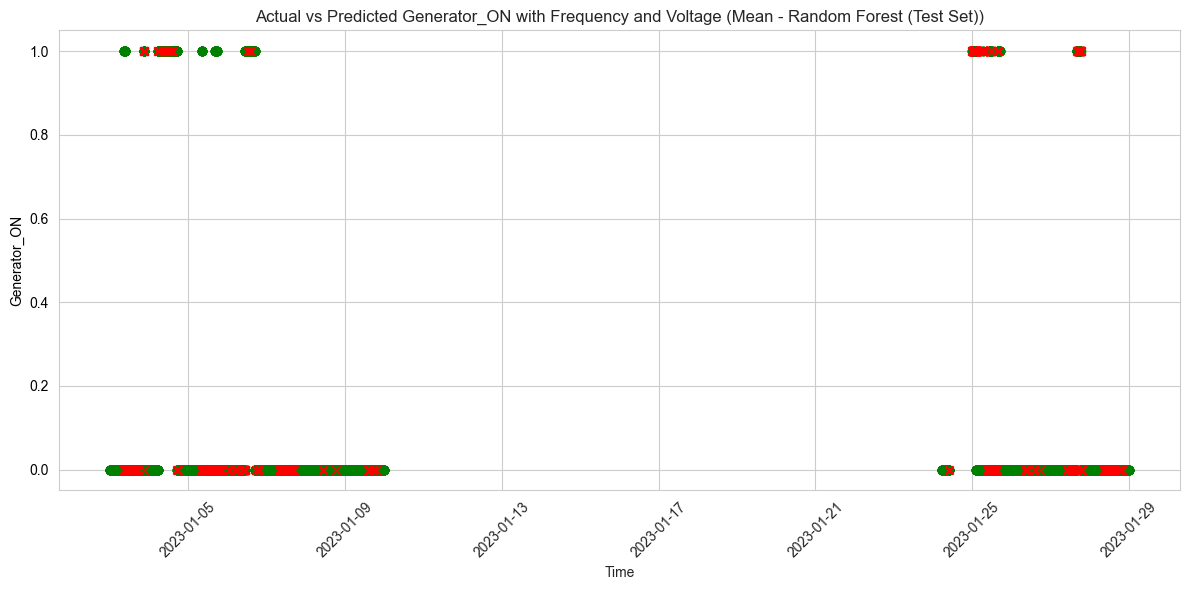

In [128]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

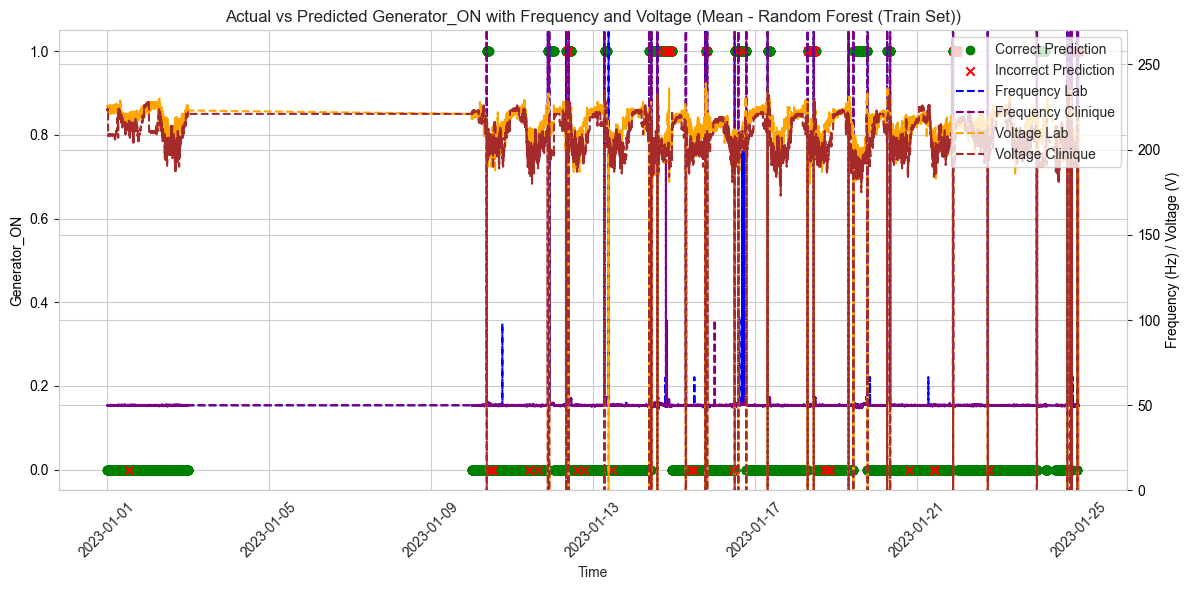

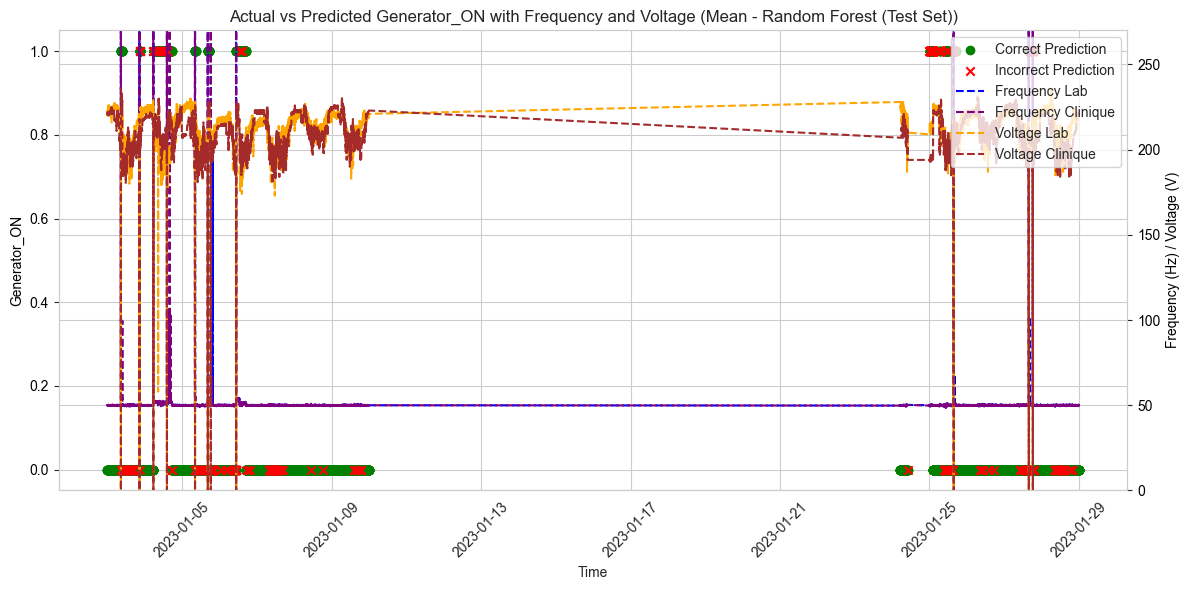

In [129]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

In [130]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_rf)
display_generator_statistics(test_data_mean_rf)

##### PREDICTION RESULT #####
Actual Minutes: 1774 minutes, or 29.57 hours within 201.60 hours
Predicted Minutes: 1712 minutes, or 28.53 hours within 201.60 hours
Actual Minutes: 869 minutes, or 14.48 hours within 134.40 hours
Predicted Minutes: 1032 minutes, or 17.20 hours within 134.40 hours


#### 4.1.4. Using Mean as a Threshold - XGBoost

Top 20 features sorted by importance (XGBoost):


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:16:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Feature,Importance
1,Frequency AEBA416D (Hgr Katwa - Cabine),0.387214
0,Frequency 1C712FB8 (Hgr Katwa - Labo),0.273554
3,Voltage AEBA416D (Hgr Katwa - Cabine),0.247882
2,Voltage 1C712FB8 (Hgr Katwa - Labo),0.091350
4,higher_freq_lab,0.000000
5,higher_freq_clinique,0.000000
6,higher_volt_lab,0.000000
7,higher_volt_clinique,0.000000


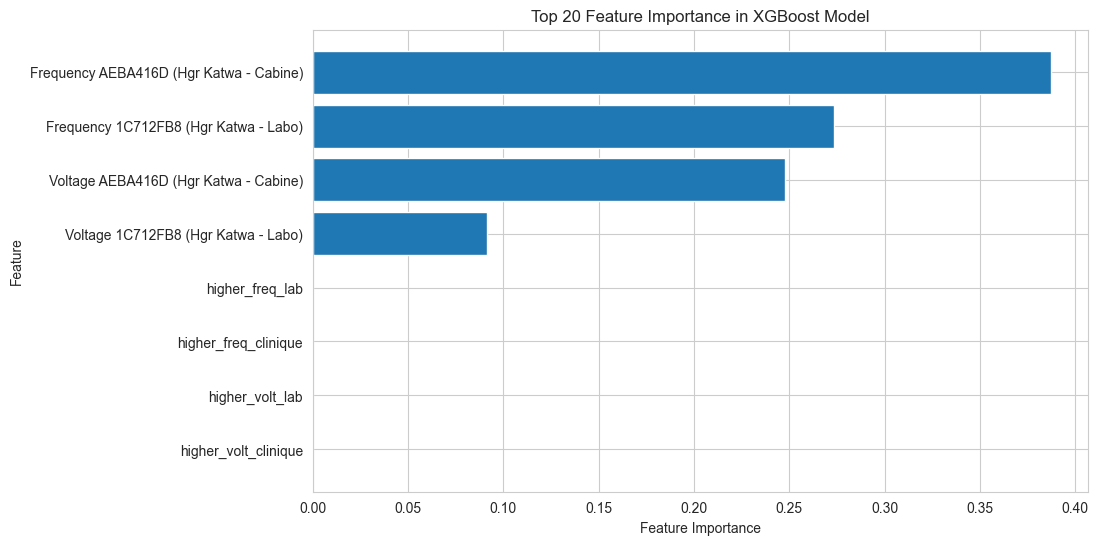

In [131]:
# Step 0: Copy rf data
train_data_mean_boost = train_data.copy()
test_data_mean_boost = test_data.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_mean_boost, test_data_mean_boost = calculate_mean_flags(train_data_mean_boost, test_data_mean_boost, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]


# Step 1: Use the same data and feature columns
X_train = train_data_mean_boost[feature_columns]
y_train = train_data_mean_boost['Generator_ON']

X_test = test_data_mean_boost[feature_columns]
y_test = test_data_mean_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
    use_label_encoder=False  # Avoid unnecessary warnings
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_boost['prediction'] = xgb_clf.predict(X_train)
test_data_mean_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

In [132]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_mean_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.9756944444444444
Confusion Matrix:
[[10280    42]
 [  252  1522]]
Precision: 0.9731457800511509
Recall: 0.8579481397970687
Train data prediction distribution (XGBoost):
prediction
0    10532
1     1564
Name: count, dtype: int64


In [133]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_mean_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):
Accuracy: 0.9527529761904762
Confusion Matrix:
[[6932  263]
 [ 118  751]]
Precision: 0.7406311637080868
Recall: 0.8642117376294591
Test data prediction distribution (XGBoost):
prediction
0    10532
1     1564
Name: count, dtype: int64


In [134]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_boost)
display_generator_statistics(test_data_mean_boost)

##### PREDICTION RESULT #####
Actual Minutes: 1774 minutes, or 29.57 hours within 201.60 hours
Predicted Minutes: 1564 minutes, or 26.07 hours within 201.60 hours
Actual Minutes: 869 minutes, or 14.48 hours within 134.40 hours
Predicted Minutes: 1014 minutes, or 16.90 hours within 134.40 hours


### 4.2. Generating Time Series Feature

In [135]:
## INITIALIZATION OF CONSTANTS
# Range of reasonable frequency and voltage
high_freq_threshold = 60
low_freq_threshold = 40

high_volt_threshold = 250
low_volt_threshold = 2

voltage_delta = 10

In [136]:
train_data_ts = train_data.copy()
test_data_ts = test_data.copy()

In [137]:
## FEATURE GENERATION
# Using mean to compare
train_data_ts, test_data_ts = calculate_mean_flags(train_data_ts, test_data_ts, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
train_data_ts, test_data_ts = process_time_series_data(train_data_ts, test_data_ts, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display the processed data
display(train_data_ts)
display(test_data_ts)

,Time,Frequency 1C712FB8 (Hgr Katwa - Labo),Frequency AEBA416D (Hgr Katwa - Cabine),Voltage 1C712FB8 (Hgr Katwa - Labo),Voltage AEBA416D (Hgr Katwa - Cabine),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
0,2023-01-01 00:00:00,50.0,49.9,225.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,2023-01-01 00:02:00,49.7,49.9,225.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,2023-01-01 00:04:00,50.1,49.8,226.0,223.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3,2023-01-01 00:06:00,50.2,49.9,226.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
4,2023-01-01 00:08:00,49.7,50.0,226.0,223.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12091,2023-01-24 05:02:00,49.9,49.9,230.0,209.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
12092,2023-01-24 05:04:00,50.1,50.0,228.0,207.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
12093,2023-01-24 05:06:00,49.9,50.0,228.0,207.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
12094,2023-01-24 05:08:00,49.9,49.9,230.0,218.0,False,False,False,True,True,...,False,False,False,False,False,True,False,False,False,False


,Time,Frequency 1C712FB8 (Hgr Katwa - Labo),Frequency AEBA416D (Hgr Katwa - Cabine),Voltage 1C712FB8 (Hgr Katwa - Labo),Voltage AEBA416D (Hgr Katwa - Cabine),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
12096,2023-01-24 05:12:00,49.8,49.8,228.0,207.0,False,False,False,True,False,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
12097,2023-01-24 05:14:00,50.0,49.9,228.0,207.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
12098,2023-01-24 05:16:00,50.0,50.0,228.0,207.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
12099,2023-01-24 05:18:00,49.8,49.9,228.0,207.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
12100,2023-01-24 05:20:00,50.0,50.0,225.0,207.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20155,2023-01-09 09:50:00,50.2,50.3,206.0,209.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
20156,2023-01-09 09:52:00,49.9,49.9,207.0,204.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20157,2023-01-09 09:54:00,49.9,49.8,208.0,204.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20158,2023-01-09 09:56:00,50.2,50.2,211.0,204.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [138]:
train_data_ts.columns

Index(['Time', 'Frequency 1C712FB8 (Hgr Katwa - Labo)',
       'Frequency AEBA416D (Hgr Katwa - Cabine)',
       'Voltage 1C712FB8 (Hgr Katwa - Labo)',
       'Voltage AEBA416D (Hgr Katwa - Cabine)', 'Generator_ON',
       'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
       'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
       'freq_delta_negative_clinique', 'volt_delta_positive_lab',
       'volt_delta_positive_clinique', 'freq_in_range_lab',
       'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
       'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
       'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
       'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
       'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
       'High_delta_freq_lab', 'High_delta_freq_clinique',
       'High_delta_vol

#### 4.2.1. Using Mean of Voltage and Frequency as a Threshold and Time Series - Logistic Regression

Train Accuracy: 0.87
Test Accuracy: 0.89
Top 20 features sorted by absolute coefficient value:


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Feature,Coefficient
48,Prev_High_delta_freq_lab,1.553969
43,Hour_23,1.292351
27,Hour_7,1.275791
44,High_delta_freq_lab,1.251507
42,Hour_22,1.120145
6,higher_volt_lab,-1.065002
7,higher_volt_clinique,-0.885138
25,Hour_5,-0.858383
24,Hour_4,-0.798320
41,Hour_21,0.791655


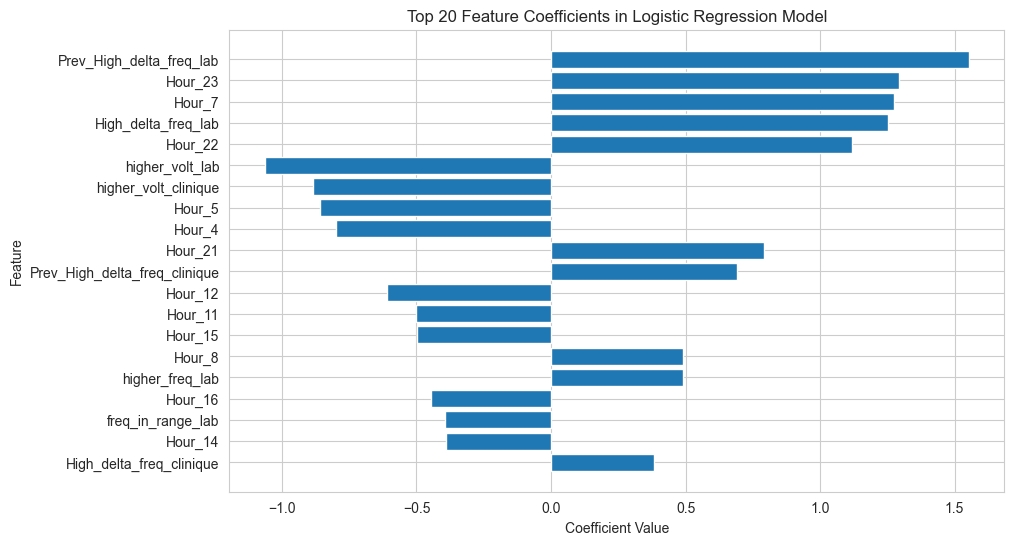

In [139]:

# Step 1: Create copies of the original data
train_data_ts_lg = train_data_ts.copy()
test_data_ts_lg = test_data_ts.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_ts_lg, test_data_ts_lg = calculate_mean_flags(train_data_ts_lg, test_data_ts_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_lg[feature_columns]
y_train = train_data_ts_lg['Generator_ON']

X_test = test_data_ts_lg[feature_columns]
y_test = test_data_ts_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Logistic Regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_lg['prediction'] = clf.predict(X_train)
test_data_ts_lg['prediction'] = clf.predict(X_test)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_ts_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_ts_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Step 4: Get the feature coefficients (importance in logistic regression)
coefficients = clf.coef_[0]  # Extract coefficients from the trained model

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients
})

# Sort the features by absolute value of the coefficient and keep the top 20
top_20_features = feature_importance_df.reindex(
    feature_importance_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

# Display the top 20 most significant features
print("Top 20 features sorted by absolute coefficient value:")
display(top_20_features)

# Visualize the top 20 feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 20 Feature Coefficients in Logistic Regression Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most significant features on top
plt.show()

In [140]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.8709490740740741
Confusion Matrix:
[[10290    32]
 [ 1529   245]]
Precision: 0.8844765342960289
Recall: 0.13810597519729426
Train data prediction distribution:
prediction
False    11819
True       277
Name: count, dtype: int64


In [141]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.8898809523809523
Confusion Matrix:
[[7154   41]
 [ 847   22]]
Precision: 0.3492063492063492
Recall: 0.02531645569620253
Test data prediction distribution:
prediction
False    8001
True       63
Name: count, dtype: int64


In [142]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_lg)
display_generator_statistics(test_data_ts_lg)

##### PREDICTION RESULT #####
Actual Minutes: 1774 minutes, or 29.57 hours within 201.60 hours
Predicted Minutes: 277 minutes, or 4.62 hours within 201.60 hours
Actual Minutes: 869 minutes, or 14.48 hours within 134.40 hours
Predicted Minutes: 63 minutes, or 1.05 hours within 134.40 hours


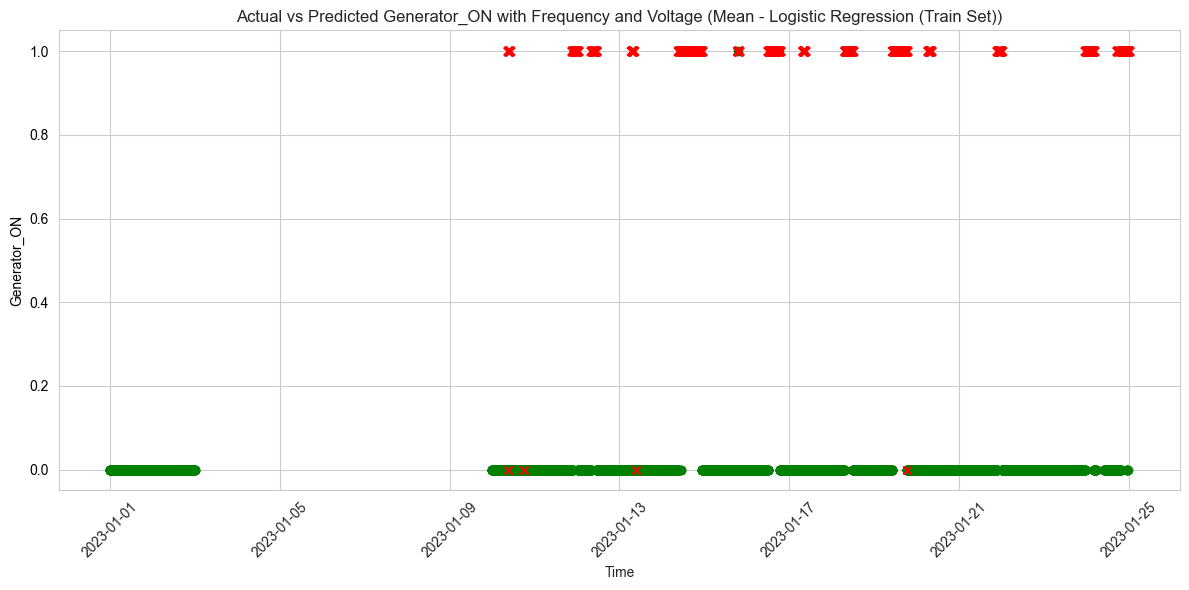

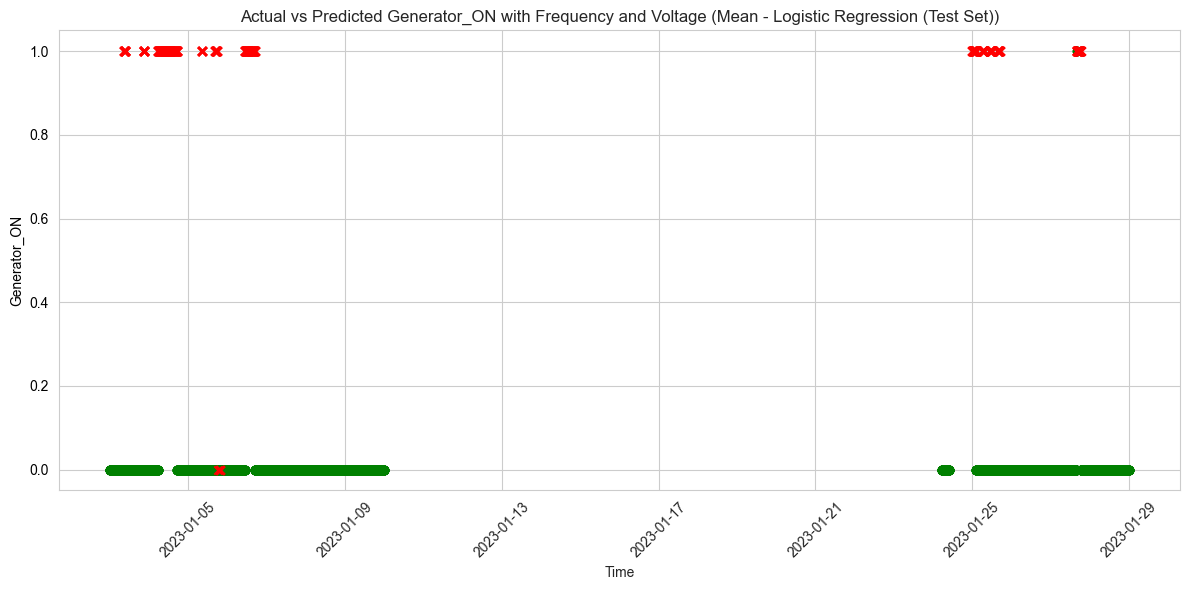

In [143]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

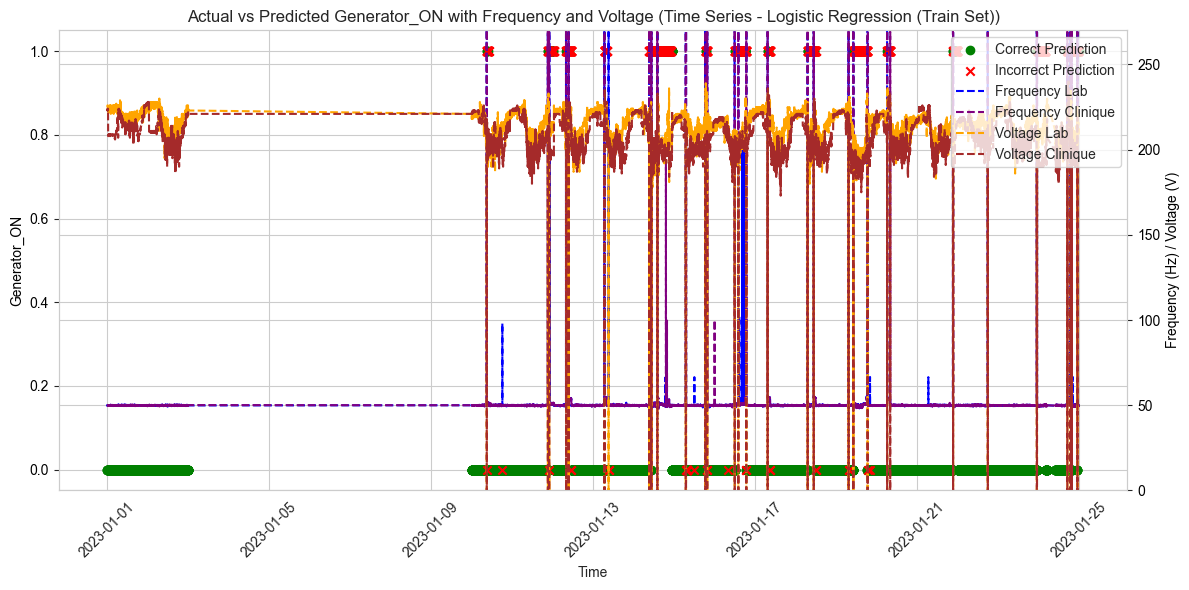

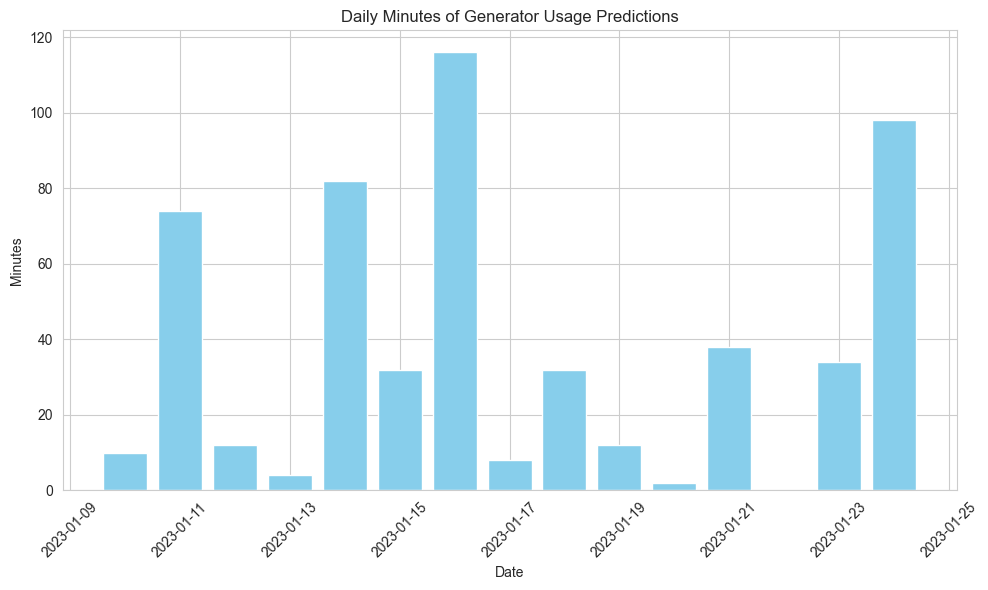

,Date,Count,Minutes,Hours
0,2023-01-10,5,10,0.166667
1,2023-01-11,37,74,1.233333
2,2023-01-12,6,12,0.200000
3,2023-01-13,2,4,0.066667
4,2023-01-14,41,82,1.366667
5,2023-01-15,16,32,0.533333
6,2023-01-16,58,116,1.933333
7,2023-01-17,4,8,0.133333
8,2023-01-18,16,32,0.533333
9,2023-01-19,6,12,0.200000


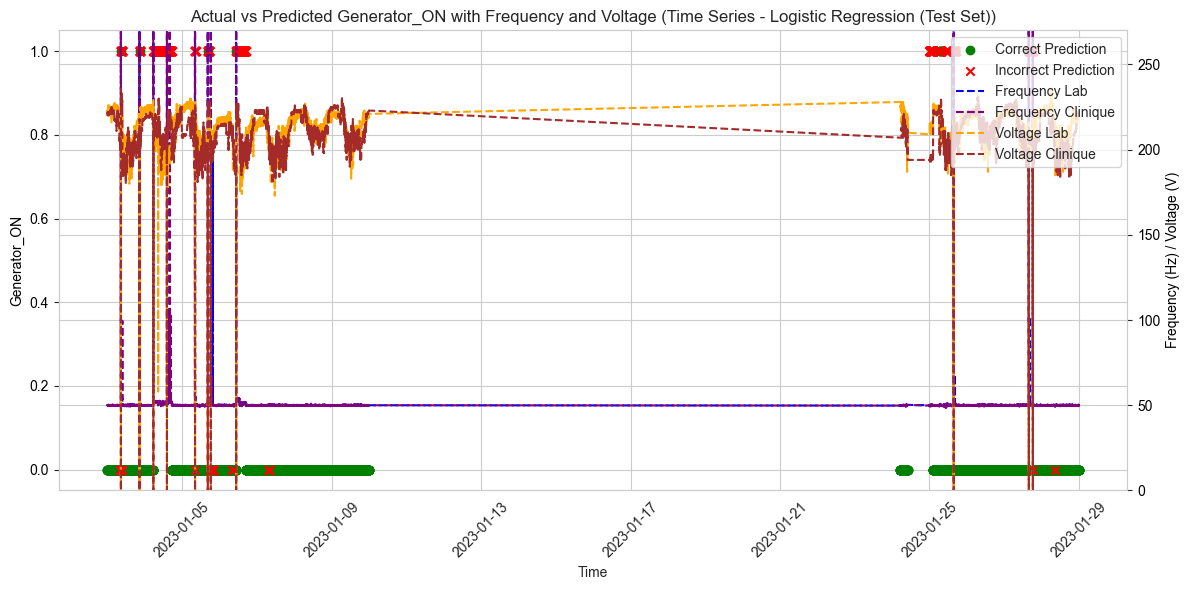

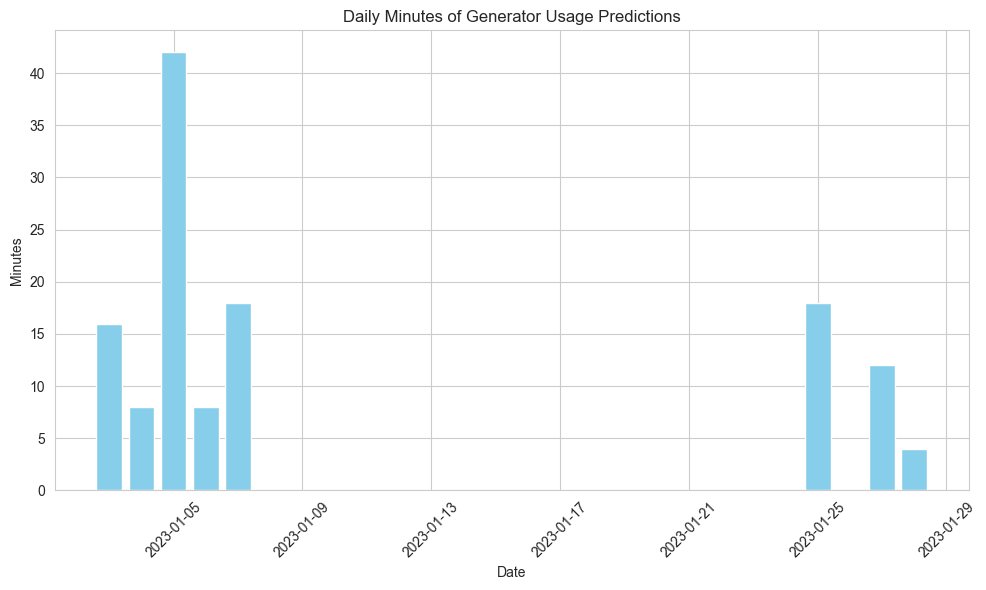

,Date,Count,Minutes,Hours
0,2023-01-03,8,16,0.266667
1,2023-01-04,4,8,0.133333
2,2023-01-05,21,42,0.700000
3,2023-01-06,4,8,0.133333
4,2023-01-07,9,18,0.300000
5,2023-01-25,9,18,0.300000
6,2023-01-27,6,12,0.200000
7,2023-01-28,2,4,0.066667


In [144]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_lg, model_name="Time Series - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_lg_daily_count = plot_true_predictions_histogram(train_data_ts_lg)
display(train_data_ts_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_lg, model_name="Time Series - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_lg_daily_count = plot_true_predictions_histogram(test_data_ts_lg)
display(test_data_ts_lg_daily_count)

#### 4.2.2. Using Mean of Voltage and Frequency as a Threshold and Time Series - Random Forrest

Top 15 features sorted by importance:


,Feature,Importance
1,Frequency AEBA416D (Hgr Katwa - Cabine),0.239163
0,Frequency 1C712FB8 (Hgr Katwa - Labo),0.234582
3,Voltage AEBA416D (Hgr Katwa - Cabine),0.092738
2,Voltage 1C712FB8 (Hgr Katwa - Labo),0.079480
9,Freq_delta_clinique,0.042932
8,Freq_delta_lab,0.042390
11,Volt_delta_clinique,0.026318
10,Volt_delta_lab,0.025289
6,higher_volt_lab,0.018703
42,Hour_22,0.018541


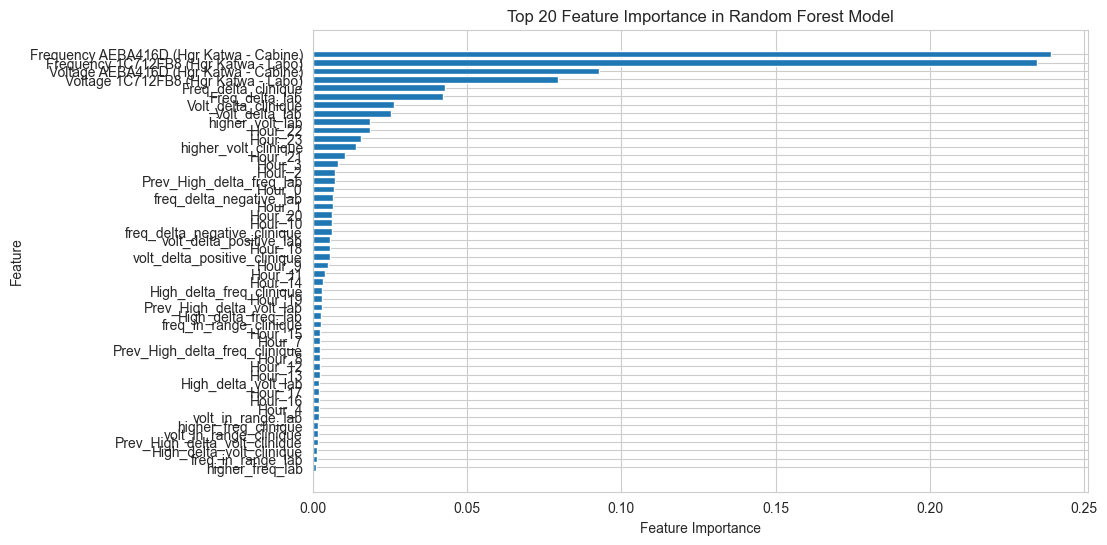

In [145]:
# Step 1: Create copies of the original data
train_data_ts_rf = train_data_ts.copy()
test_data_ts_rf = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_rf, test_data_ts_rf = calculate_mean_flags(train_data_ts_rf, test_data_ts_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_rf[feature_columns]
y_train = train_data_ts_rf['Generator_ON']

X_test = test_data_ts_rf[feature_columns]
y_test = test_data_ts_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_rf['prediction'] = clf.predict(X_train)
test_data_ts_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(50)

# Display the top 15 most important features
print("Top 15 features sorted by importance:")
display(top_15_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_15_features['Feature'], top_15_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

Evaluating the train and test set

In [146]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 1.0
Confusion Matrix:
[[10322     0]
 [    0  1774]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution:
prediction
False    10322
True      1774
Name: count, dtype: int64


In [147]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9692460317460317
Confusion Matrix:
[[7033  162]
 [  86  783]]
Precision: 0.8285714285714286
Recall: 0.9010356731875719
Test data prediction distribution:
prediction
False    7119
True      945
Name: count, dtype: int64


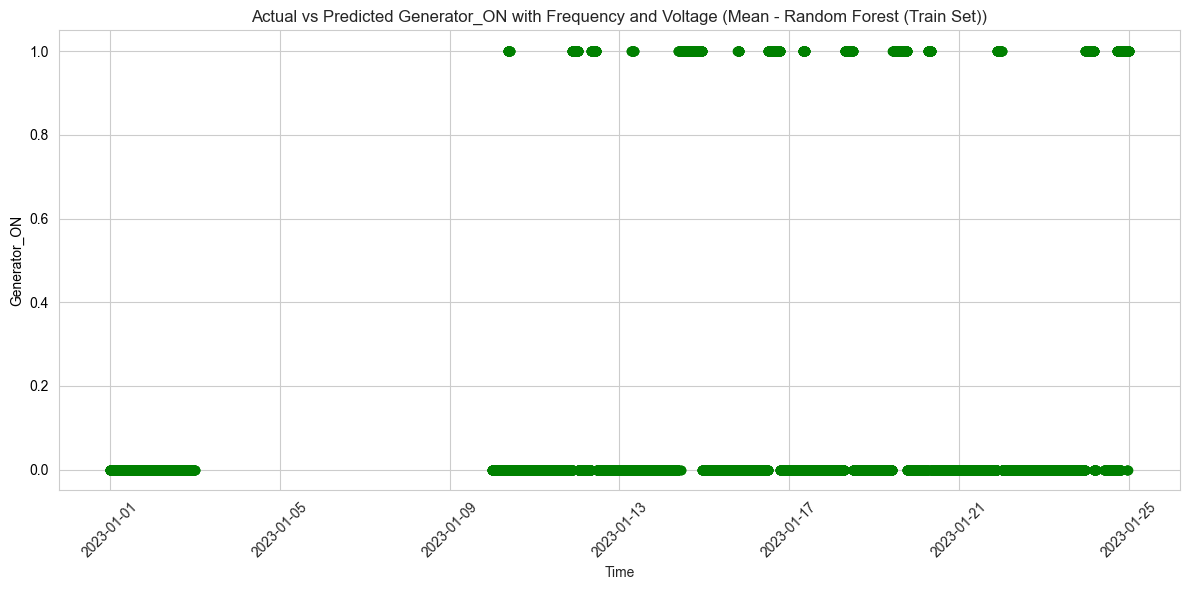

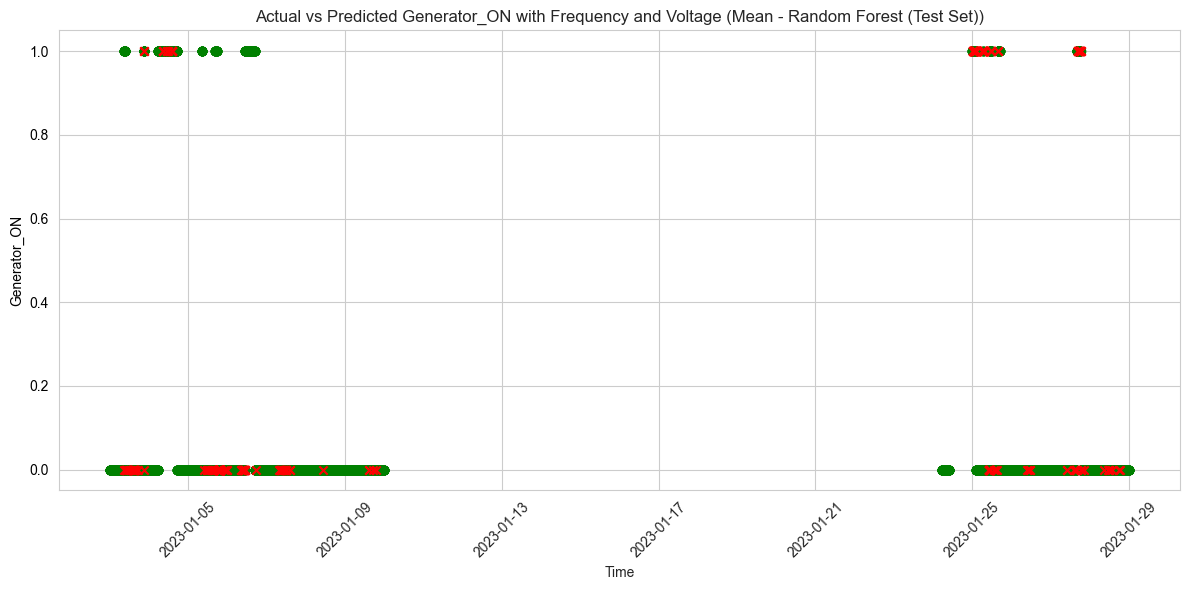

In [148]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

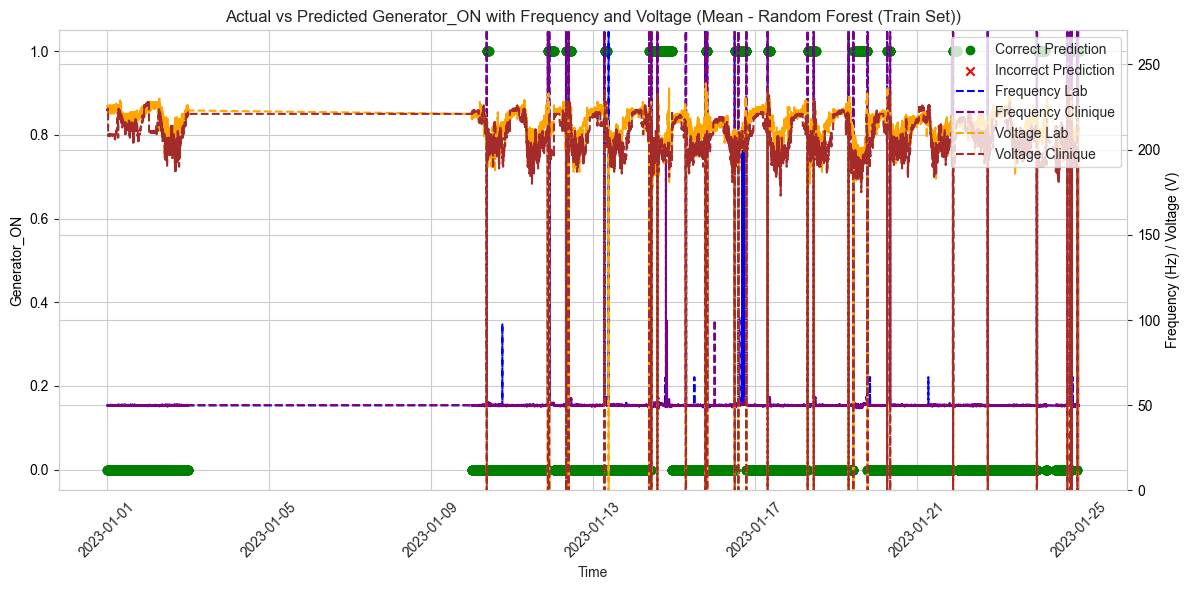

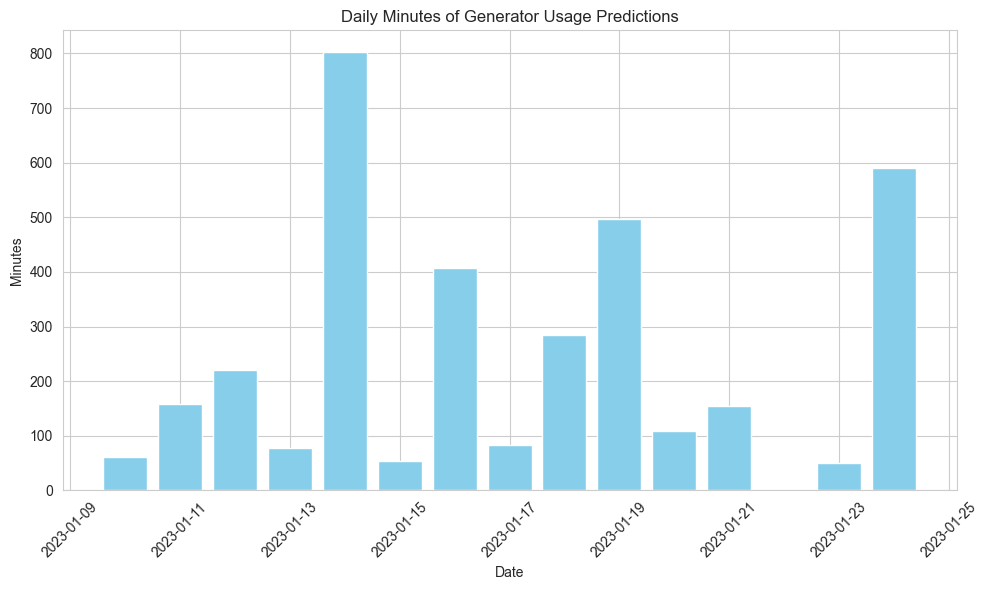

,Date,Count,Minutes,Hours
0,2023-01-10,31,62,1.033333
1,2023-01-11,79,158,2.633333
2,2023-01-12,110,220,3.666667
3,2023-01-13,39,78,1.300000
4,2023-01-14,401,802,13.366667
5,2023-01-15,27,54,0.900000
6,2023-01-16,204,408,6.800000
7,2023-01-17,42,84,1.400000
8,2023-01-18,142,284,4.733333
9,2023-01-19,248,496,8.266667


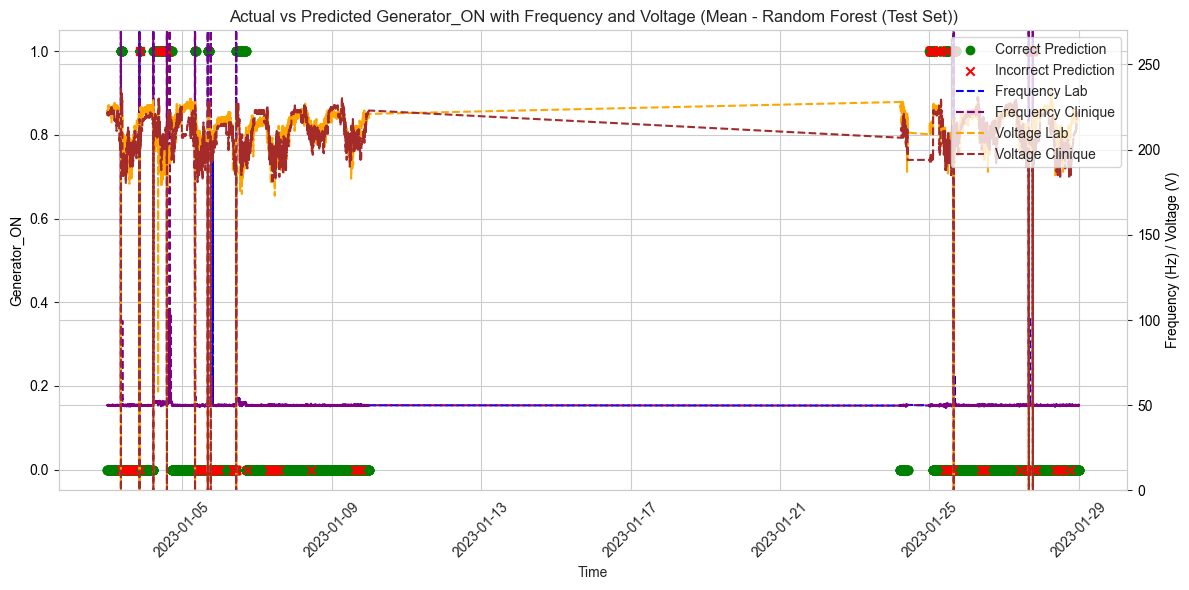

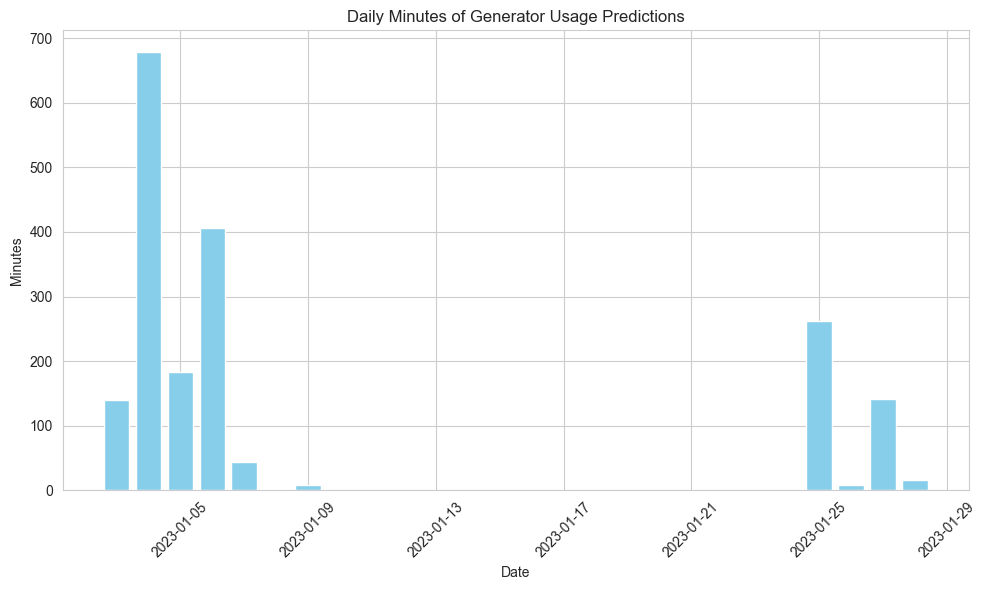

,Date,Count,Minutes,Hours
0,2023-01-03,70,140,2.333333
1,2023-01-04,339,678,11.300000
2,2023-01-05,92,184,3.066667
3,2023-01-06,203,406,6.766667
4,2023-01-07,22,44,0.733333
5,2023-01-08,1,2,0.033333
6,2023-01-09,4,8,0.133333
7,2023-01-25,131,262,4.366667
8,2023-01-26,4,8,0.133333
9,2023-01-27,71,142,2.366667


In [149]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_rf_daily_count = plot_true_predictions_histogram(train_data_ts_rf)
display(train_data_ts_rf_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_rf_daily_count = plot_true_predictions_histogram(test_data_ts_rf)
display(test_data_ts_rf_daily_count)

In [150]:
train_data_ts_rf['Generator_ON'].dtype

dtype('bool')

In [151]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_rf)
display_generator_statistics(test_data_ts_rf)

##### PREDICTION RESULT #####
Actual Minutes: 1774 minutes, or 29.57 hours within 201.60 hours
Predicted Minutes: 1774 minutes, or 29.57 hours within 201.60 hours
Actual Minutes: 869 minutes, or 14.48 hours within 134.40 hours
Predicted Minutes: 945 minutes, or 15.75 hours within 134.40 hours


#### 4.2.3. Using Mean of Voltage and Frequency as a Threshold and Time Series - XGBoost

In [152]:

# Step 0: Copy rf data
train_data_ts_boost = train_data_ts.copy()
test_data_ts_boost = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_boost, test_data_ts_boost = calculate_mean_flags(train_data_ts_boost, test_data_ts_boost, train_data_base, columns_to_compare)


# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]


# Step 1: Use the same data and feature columns
X_train = train_data_ts_boost[feature_columns]
y_train = train_data_ts_boost['Generator_ON']

X_test = test_data_ts_boost[feature_columns]
y_test = test_data_ts_boost['Generator_ON']

X_train['Prev_High_delta_freq_lab'] = pd.to_numeric(X_train['Prev_High_delta_freq_lab'], errors='coerce')
X_train['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_train['Prev_High_delta_freq_clinique'], errors='coerce')
X_train['Prev_High_delta_volt_lab'] = pd.to_numeric(X_train['Prev_High_delta_volt_lab'], errors='coerce')
X_train['Prev_High_delta_volt_clinique'] = pd.to_numeric(X_train['Prev_High_delta_volt_clinique'], errors='coerce')

X_test['Prev_High_delta_freq_lab'] = pd.to_numeric(X_test['Prev_High_delta_freq_lab'], errors='coerce')
X_test['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_test['Prev_High_delta_freq_clinique'], errors='coerce')
X_test['Prev_High_delta_volt_lab'] = pd.to_numeric(X_test['Prev_High_delta_volt_lab'], errors='coerce')
X_test['Prev_High_delta_volt_clinique'] = pd.to_numeric(X_test['Prev_High_delta_volt_clinique'], errors='coerce')


/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_49853/3060535340.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Prev_High_delta_freq_lab'] = pd.to_numeric(X_train['Prev_High_delta_freq_lab'], errors='coerce')
/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_49853/3060535340.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_train['Prev_High_delta_freq_clinique'], errors='coerce')
/var/folders/fz/752v568s4vs79b77

#### This section is for XGBoost parameter search using cross validation

In [153]:

'''
# Step 2: Train an XGBoost Classifier
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',  # Adjust based on your metric
    cv=3,               # Cross-validation splits
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


# Step 3: Make Predictions on the train and test sets
train_data_ts_boost['prediction'] = xgb_clf.predict(X_train)
test_data_ts_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()
'''

'\n# Step 2: Train an XGBoost Classifier\nparam_grid = {\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'n_estimators\': [100, 300, 500],\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'colsample_bytree\': [0.6, 0.8, 1.0],\n    \'gamma\': [0, 1, 5],\n    \'reg_alpha\': [0, 0.1, 1],\n    \'reg_lambda\': [1, 10, 100]\n}\n\ngrid_search = GridSearchCV(\n    estimator=XGBClassifier(random_state=42),\n    param_grid=param_grid,\n    scoring=\'roc_auc\',  # Adjust based on your metric\n    cv=3,               # Cross-validation splits\n    verbose=2\n)\n\ngrid_search.fit(X_train, y_train)\n\nprint("Best parameters:", grid_search.best_params_)\n\n\n# Step 3: Make Predictions on the train and test sets\ntrain_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_train)\ntest_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_test)\n\n# Step 4: Evaluate Feature Importances\nimportances = xgb_clf.feature_importances_\n\n# Create a DataFrame for better visualization\nfeature

In [154]:
# Use the best parameters from GridSearchCV
best_params = {
    'colsample_bytree': 0.6,
    'gamma': 0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 300,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'subsample': 1.0
}

# Initialize the model with the best parameters
final_model = XGBClassifier(
    random_state=42,
    **best_params
)

# Fit the model on the entire training data
final_model.fit(X_train, y_train)

# Make predictions on the test set
train_data_ts_boost['prediction'] = final_model.predict(X_train)
test_data_ts_boost['prediction'] = final_model.predict(X_test)

# Evaluate the model on the test set
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Classification report
print("Classification Report:")
print(classification_report(y_test, test_data_ts_boost['prediction']))

# AUC-ROC score
print("AUC-ROC Score:")
y_test_proba = final_model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_test_proba))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_data_ts_boost['prediction']))

Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.97      0.98      7195
        True       0.80      0.89      0.84       869

    accuracy                           0.96      8064
   macro avg       0.90      0.93      0.91      8064
weighted avg       0.97      0.96      0.97      8064

AUC-ROC Score:
0.9831419018609491
Confusion Matrix:
[[7008  187]
 [  99  770]]


In [155]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_ts_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_ts_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.9798280423280423
Confusion Matrix:
[[10288    34]
 [  210  1564]]
Precision: 0.9787234042553191
Recall: 0.8816234498308907
Train data prediction distribution (XGBoost):
prediction
0    10498
1     1598
Name: count, dtype: int64


In [156]:
# Evaluate on the test set
print("\nTest Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_ts_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(test_data_ts_boost['prediction'].value_counts())


Test Set Evaluation (XGBoost):
Accuracy: 0.9645337301587301
Confusion Matrix:
[[7008  187]
 [  99  770]]
Precision: 0.8045977011494253
Recall: 0.8860759493670886
Test data prediction distribution (XGBoost):
prediction
0    7107
1     957
Name: count, dtype: int64


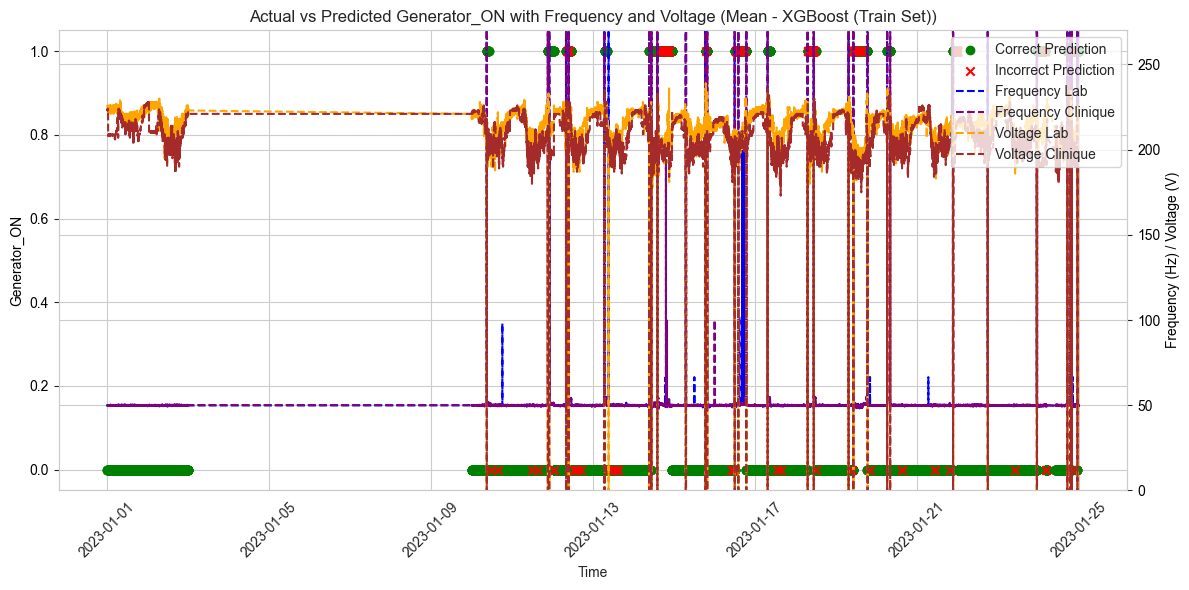

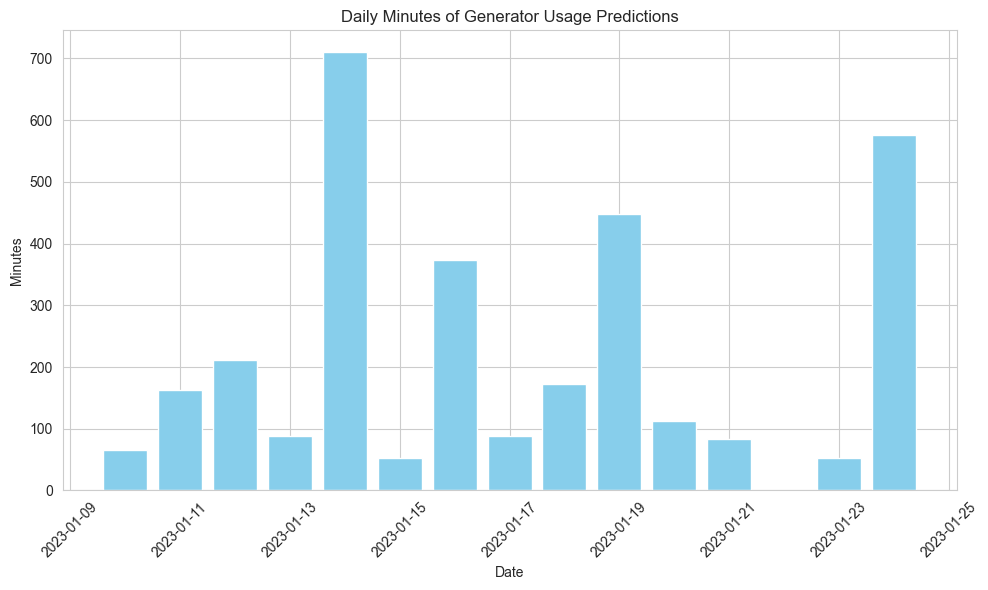

,Date,Count,Minutes,Hours
0,2023-01-10,33,66,1.100000
1,2023-01-11,81,162,2.700000
2,2023-01-12,106,212,3.533333
3,2023-01-13,44,88,1.466667
4,2023-01-14,355,710,11.833333
5,2023-01-15,26,52,0.866667
6,2023-01-16,187,374,6.233333
7,2023-01-17,44,88,1.466667
8,2023-01-18,86,172,2.866667
9,2023-01-19,224,448,7.466667


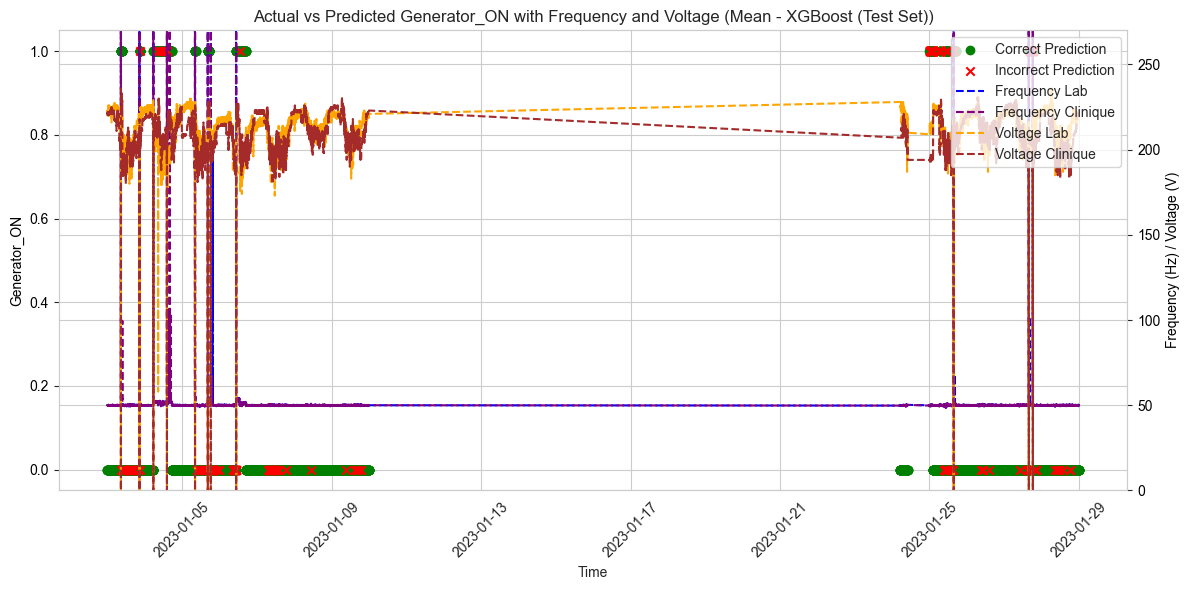

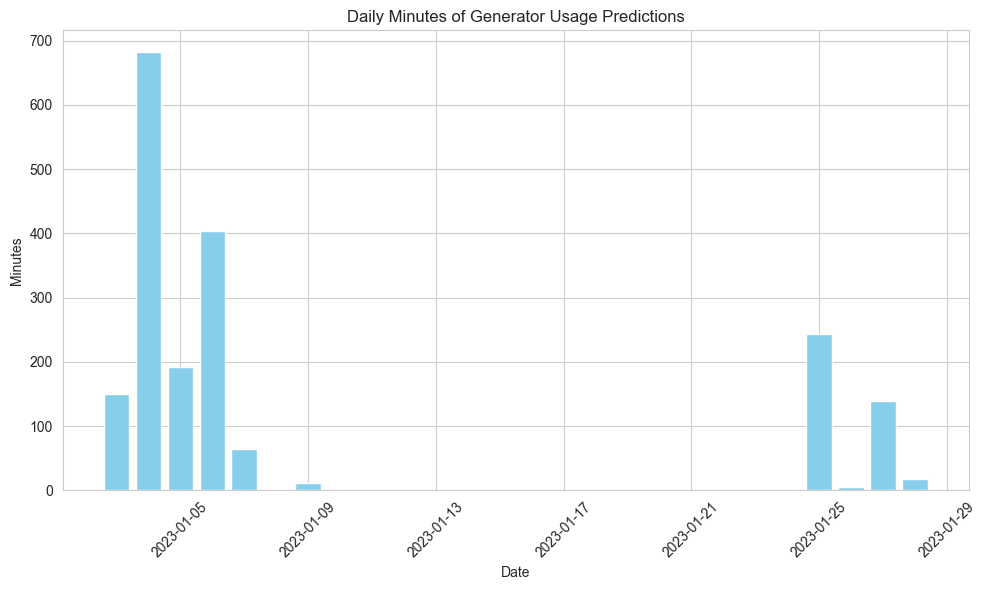

,Date,Count,Minutes,Hours
0,2023-01-03,75,150,2.500000
1,2023-01-04,341,682,11.366667
2,2023-01-05,96,192,3.200000
3,2023-01-06,202,404,6.733333
4,2023-01-07,32,64,1.066667
5,2023-01-08,1,2,0.033333
6,2023-01-09,6,12,0.200000
7,2023-01-25,122,244,4.066667
8,2023-01-26,3,6,0.100000
9,2023-01-27,70,140,2.333333


In [157]:
# For Boosting Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_boost, model_name="Mean - XGBoost (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_boost_daily_count = plot_true_predictions_histogram(train_data_ts_boost)
display(train_data_ts_boost_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_boost, model_name="Mean - XGBoost (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_boost_daily_count = plot_true_predictions_histogram(test_data_ts_boost)
display(test_data_ts_boost_daily_count)

In [158]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_boost)
display_generator_statistics(test_data_ts_boost)

##### PREDICTION RESULT #####
Actual Minutes: 1774 minutes, or 29.57 hours within 201.60 hours
Predicted Minutes: 1598 minutes, or 26.63 hours within 201.60 hours
Actual Minutes: 869 minutes, or 14.48 hours within 134.40 hours
Predicted Minutes: 957 minutes, or 15.95 hours within 134.40 hours


### 4.3. Correlation Feature

In this section we're applying additional feature using the : 
- Hidden Markov Model : Detecting states

In [159]:
### Applying Hidden Markov Model

# Insert variables
n_states = 5
hmm_columns = [freq_a, freq_b, volt_a, volt_b]

# Make copies of original train and test sets
train_data_ts_co = train_data_ts.copy()
test_data_ts_co = test_data_ts.copy()

# Sort by Time
train_data_ts_co.sort_values('Time', ascending=True, inplace=True)
test_data_ts_co.sort_values('Time', ascending=True, inplace=True)

# Clean NaNs, infs, and low-variance columns
valid_hmm_columns = []

for col in hmm_columns:
    if col in train_data_ts_co.columns and col in test_data_ts_co.columns:
        values_train = train_data_ts_co[col].replace([np.inf, -np.inf], 0).fillna(0)
        values_test = test_data_ts_co[col].replace([np.inf, -np.inf], 0).fillna(0)

        if values_train.std() < 1e-3:
            print(f"⚠️ Column {col} has too low variance (std={values_train.std():.5f}), skipping HMM fitting.")
        else:
            train_data_ts_co[col] = values_train
            test_data_ts_co[col] = values_test
            valid_hmm_columns.append(col)

hmm_columns = valid_hmm_columns  # update hmm_columns

# Train HMMs on train set
train_data_ts_co, hmm_models, hmm_features = generate_hmm(
    train_data_ts_co,
    hmm_columns,
    n_states=n_states
)

# Apply HMMs to test set
def apply_hmm(df, columns, hmm_models):
    """
    Apply trained HMM models to a new dataset and generate one-hot encoded HMM states.

    Parameters:
    - df (DataFrame): The DataFrame to apply HMMs to.
    - columns (list): List of feature columns to apply HMMs.
    - hmm_models (dict): Trained HMM models from the training set.

    Returns:
    - df_result (DataFrame): DataFrame with added HMM states and one-hot encoded features.
    """
    df_result = df.copy()
    hmm_feature_cols = []

    for col in columns:
        if col not in df_result.columns:
            print(f"⚠️ Column {col} missing in DataFrame. Skipping...")
            continue

        X = df_result[col].replace([np.inf, -np.inf], 0).fillna(0).to_numpy().reshape(-1, 1)
        state_col = f'HMM_State_{col}'
        model = hmm_models.get(col)

        if model is not None:
            df_result[state_col] = model.predict(X)

            # One-hot encode HMM state
            dummies = pd.get_dummies(df_result[state_col], prefix=state_col)
            df_result = pd.concat([df_result, dummies], axis=1)
            hmm_feature_cols.extend(dummies.columns.tolist())
        else:
            print(f"⚠️ No trained HMM model found for {col}. Skipping...")

    return df_result

# Now apply
test_data_ts_co = apply_hmm(test_data_ts_co, hmm_columns, hmm_models)

# Display result
display(train_data_ts_co)
display(test_data_ts_co)


,Time,Frequency 1C712FB8 (Hgr Katwa - Labo),Frequency AEBA416D (Hgr Katwa - Cabine),Voltage 1C712FB8 (Hgr Katwa - Labo),Voltage AEBA416D (Hgr Katwa - Cabine),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_1,HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_2,HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_3,HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_4,HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine),HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_0,HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_1,HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_2,HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_3,HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_4
0,2023-01-01 00:00:00,50.0,49.9,225.0,224.0,False,False,False,True,True,...,False,False,False,True,2,False,False,True,False,False
1,2023-01-01 00:02:00,49.7,49.9,225.0,224.0,False,False,False,True,True,...,False,False,False,False,2,False,False,True,False,False
2,2023-01-01 00:04:00,50.1,49.8,226.0,223.0,False,False,False,True,True,...,False,False,False,True,2,False,False,True,False,False
3,2023-01-01 00:06:00,50.2,49.9,226.0,224.0,False,False,False,True,True,...,False,False,False,False,2,False,False,True,False,False
4,2023-01-01 00:08:00,49.7,50.0,226.0,223.0,False,False,False,True,True,...,False,False,False,True,2,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,2023-01-24 23:50:00,49.7,49.6,211.0,195.0,True,False,False,False,False,...,False,False,True,False,0,True,False,False,False,False
11996,2023-01-24 23:52:00,49.6,49.5,212.0,196.0,True,False,False,False,False,...,False,False,True,False,4,False,False,False,False,True
11997,2023-01-24 23:54:00,49.6,50.0,213.0,195.0,True,False,False,False,False,...,False,False,True,False,0,True,False,False,False,False
11998,2023-01-24 23:56:00,50.0,49.7,211.0,195.0,True,False,False,False,False,...,False,False,True,False,4,False,False,False,False,True


,Time,Frequency 1C712FB8 (Hgr Katwa - Labo),Frequency AEBA416D (Hgr Katwa - Cabine),Voltage 1C712FB8 (Hgr Katwa - Labo),Voltage AEBA416D (Hgr Katwa - Cabine),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_1,HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_2,HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_3,HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_4,HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine),HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_0,HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_1,HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_2,HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_3,HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_4
15120,2023-01-03 00:00:00,49.5,49.8,222.0,220.0,False,False,False,True,True,...,False,False,False,True,2,False,False,True,False,False
15121,2023-01-03 00:02:00,49.8,49.8,223.0,221.0,False,False,False,True,True,...,False,False,False,False,2,False,False,True,False,False
15122,2023-01-03 00:04:00,50.1,49.9,221.0,221.0,False,False,False,True,True,...,False,False,False,True,2,False,False,True,False,False
15123,2023-01-03 00:06:00,50.1,50.1,221.0,221.0,False,False,False,True,True,...,False,False,False,False,2,False,False,True,False,False
15124,2023-01-03 00:08:00,49.9,49.8,221.0,221.0,False,False,False,True,True,...,False,False,False,True,2,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14875,2023-01-28 23:50:00,50.0,50.0,220.0,221.0,False,False,False,True,True,...,False,False,False,True,2,False,False,True,False,False
14876,2023-01-28 23:52:00,49.8,49.8,220.0,220.0,False,False,False,True,True,...,False,False,False,False,2,False,False,True,False,False
14877,2023-01-28 23:54:00,49.9,49.9,220.0,221.0,False,False,False,True,True,...,False,False,False,True,2,False,False,True,False,False
14878,2023-01-28 23:56:00,50.0,50.0,221.0,221.0,False,False,False,True,True,...,False,False,False,False,2,False,False,True,False,False



Mean values per HMM state for Frequency 1C712FB8 (Hgr Katwa - Labo):
HMM_State_Frequency 1C712FB8 (Hgr Katwa - Labo)
0      49.943257
3      52.592157
1     101.416667
4    5312.888889
Name: Frequency 1C712FB8 (Hgr Katwa - Labo), dtype: float64


/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_49853/3142872855.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.sort_values('Time', ascending=True, inplace=True)


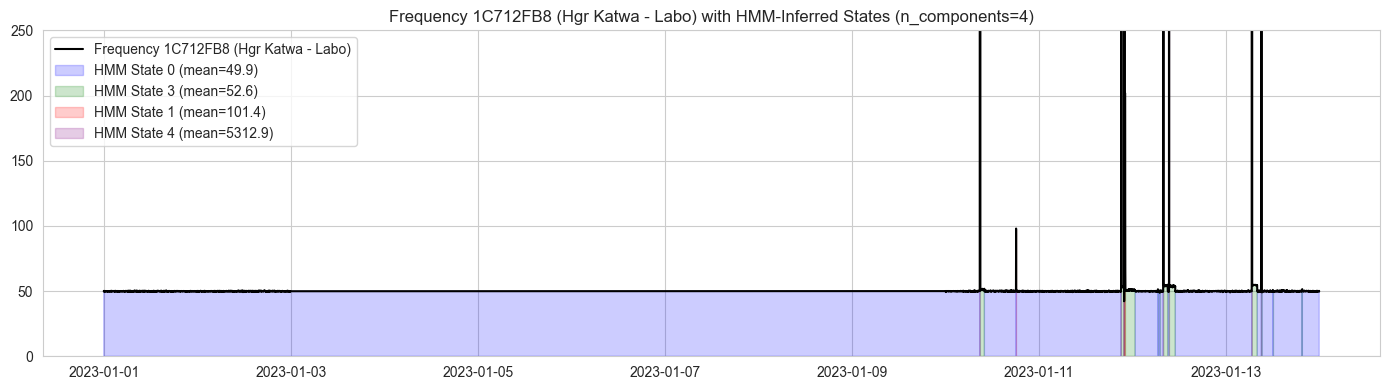


Mean values per HMM state for Frequency AEBA416D (Hgr Katwa - Cabine):
HMM_State_Frequency AEBA416D (Hgr Katwa - Cabine)
0      49.940212
2      52.678486
4    3699.333333
1    5820.666667
3    9804.000000
Name: Frequency AEBA416D (Hgr Katwa - Cabine), dtype: float64


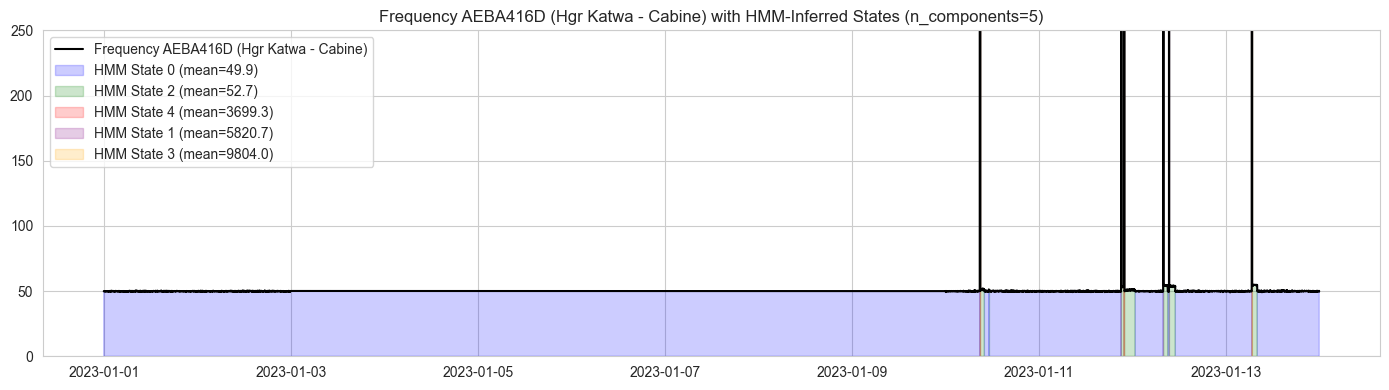


Mean values per HMM state for Voltage 1C712FB8 (Hgr Katwa - Labo):
HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)
1      0.632105
2    205.515789
3    215.230853
0    222.740642
4    222.746667
Name: Voltage 1C712FB8 (Hgr Katwa - Labo), dtype: float64


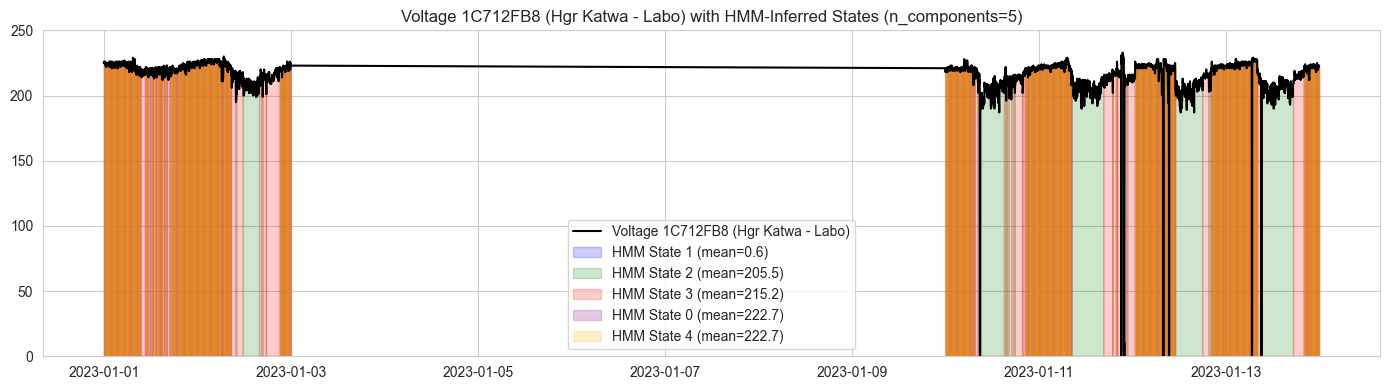


Mean values per HMM state for Voltage AEBA416D (Hgr Katwa - Cabine):
HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)
1      0.000000
0    200.087366
4    200.134409
3    210.952518
2    221.034410
Name: Voltage AEBA416D (Hgr Katwa - Cabine), dtype: float64


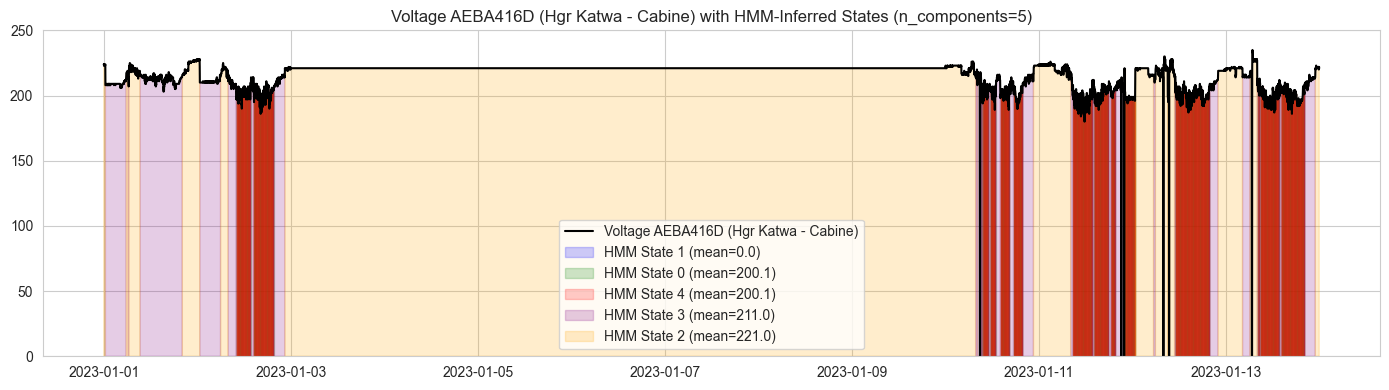

In [160]:
#### SHOWING THE RESULT OF HMM SIGNAL
    
# Create the signal
start_date = '2023-01-01 00:00:00'
finished_date = '2023-01-13 23:59:59'
filtered_data = train_data_ts_co[(train_data_ts_co['Time'] >= start_date) & (train_data_ts_co['Time'] <= finished_date)]
filtered_data.sort_values('Time', ascending=True, inplace=True)

show_hmm_result(filtered_data, hmm_columns, y_max=250)

In [161]:
hmm_features

['HMM_State_Frequency 1C712FB8 (Hgr Katwa - Labo)_0',
 'HMM_State_Frequency 1C712FB8 (Hgr Katwa - Labo)_1',
 'HMM_State_Frequency 1C712FB8 (Hgr Katwa - Labo)_2',
 'HMM_State_Frequency 1C712FB8 (Hgr Katwa - Labo)_3',
 'HMM_State_Frequency 1C712FB8 (Hgr Katwa - Labo)_4',
 'HMM_State_Frequency AEBA416D (Hgr Katwa - Cabine)_0',
 'HMM_State_Frequency AEBA416D (Hgr Katwa - Cabine)_1',
 'HMM_State_Frequency AEBA416D (Hgr Katwa - Cabine)_2',
 'HMM_State_Frequency AEBA416D (Hgr Katwa - Cabine)_3',
 'HMM_State_Frequency AEBA416D (Hgr Katwa - Cabine)_4',
 'HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_0',
 'HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_1',
 'HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_2',
 'HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_3',
 'HMM_State_Voltage 1C712FB8 (Hgr Katwa - Labo)_4',
 'HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_0',
 'HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_1',
 'HMM_State_Voltage AEBA416D (Hgr Katwa - Cabine)_2',
 'HMM_State_Voltage AEBA416D

#### 4.3.1. Adding the Correlation functions (HMM and Ruptures)  - Logistic Regression

Train Accuracy: 0.97
Test Accuracy: 0.97
Top 20 features sorted by absolute coefficient value:


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Feature,Coefficient
43,Hour_23,4.705611
42,Hour_22,4.109963
59,HMM_State_Frequency AEBA416D (Hgr Katwa - Cabi...,3.454789
35,Hour_15,-2.962631
32,Hour_12,-2.881657
57,HMM_State_Frequency AEBA416D (Hgr Katwa - Cabi...,-2.782573
55,HMM_State_Frequency 1C712FB8 (Hgr Katwa - Labo)_3,2.703570
36,Hour_16,-2.701569
31,Hour_11,-2.513334
52,HMM_State_Frequency 1C712FB8 (Hgr Katwa - Labo)_0,-2.397596


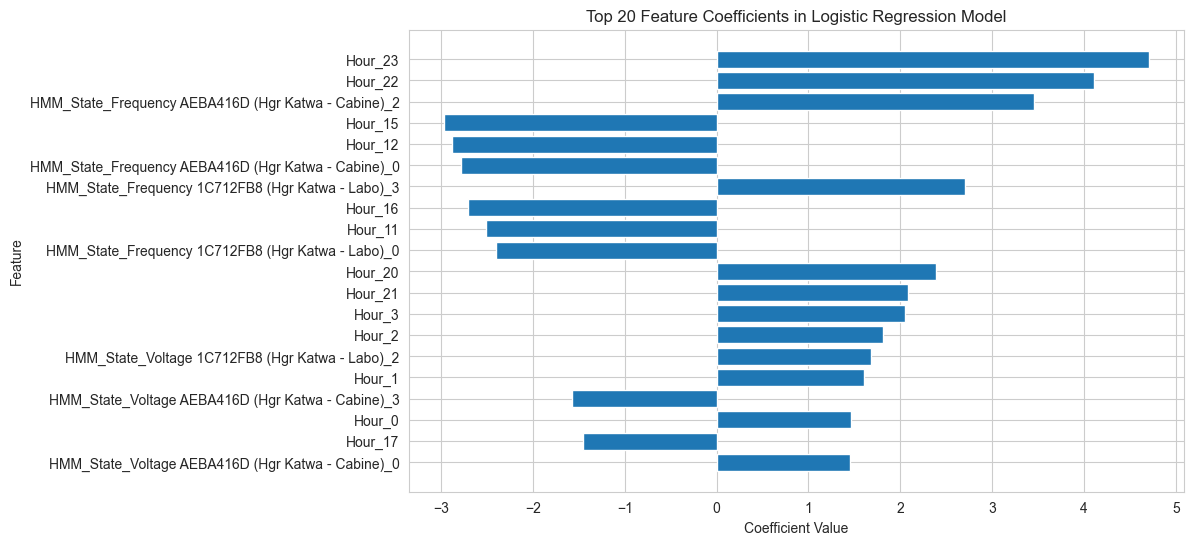

In [162]:
# Step 1: Create copies of the original data
train_data_ts_co_lg = train_data_ts_co.copy()
test_data_ts_co_lg = test_data_ts_co.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_ts_co_lg, test_data_ts_co_lg = calculate_mean_flags(train_data_ts_co_lg, test_data_ts_co_lg, train_data_base,
                                                         columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a,
    freq_b,
    volt_a,
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

feature_columns = feature_columns + hmm_features

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_co_lg[feature_columns]
y_train = train_data_ts_co_lg['Generator_ON']

X_test = test_data_ts_co_lg[feature_columns]
y_test = test_data_ts_co_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Logistic Regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_co_lg['prediction'] = clf.predict(X_train)
test_data_ts_co_lg['prediction'] = clf.predict(X_test)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_ts_co_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_ts_co_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Step 4: Get the feature coefficients (importance in logistic regression)
coefficients = clf.coef_[0]  # Extract coefficients from the trained model

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients
})

# Sort the features by absolute value of the coefficient and keep the top 20
top_20_features = feature_importance_df.reindex(
    feature_importance_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

# Display the top 20 most significant features
print("Top 20 features sorted by absolute coefficient value:")
display(top_20_features)

# Visualize the top 20 feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 20 Feature Coefficients in Logistic Regression Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most significant features on top
plt.show()

In [163]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_co_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_co_lg['prediction'].value_counts())

# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_co_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_co_lg['prediction'].value_counts())

print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_lg)
display_generator_statistics(test_data_ts_co_lg)

Train Set Evaluation:
Accuracy: 0.9719742063492064
Confusion Matrix:
[[10281    41]
 [  298  1476]]
Precision: 0.972972972972973
Recall: 0.8320180383314544
Train data prediction distribution:
prediction
False    10579
True      1517
Name: count, dtype: int64
Test Set Evaluation:
Accuracy: 0.9697420634920635
Confusion Matrix:
[[7093  102]
 [ 142  727]]
Precision: 0.8769601930036188
Recall: 0.8365937859608745
Test data prediction distribution:
prediction
False    7235
True      829
Name: count, dtype: int64
##### PREDICTION RESULT #####
Actual Minutes: 1774 minutes, or 29.57 hours within 201.60 hours
Predicted Minutes: 1517 minutes, or 25.28 hours within 201.60 hours
Actual Minutes: 869 minutes, or 14.48 hours within 134.40 hours
Predicted Minutes: 829 minutes, or 13.82 hours within 134.40 hours


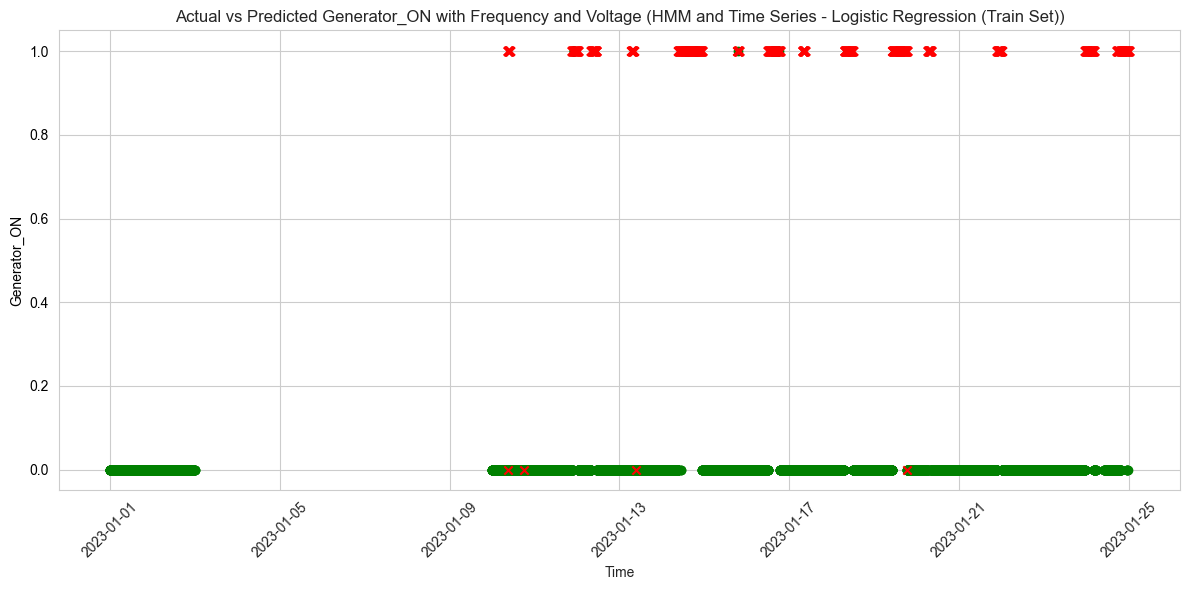

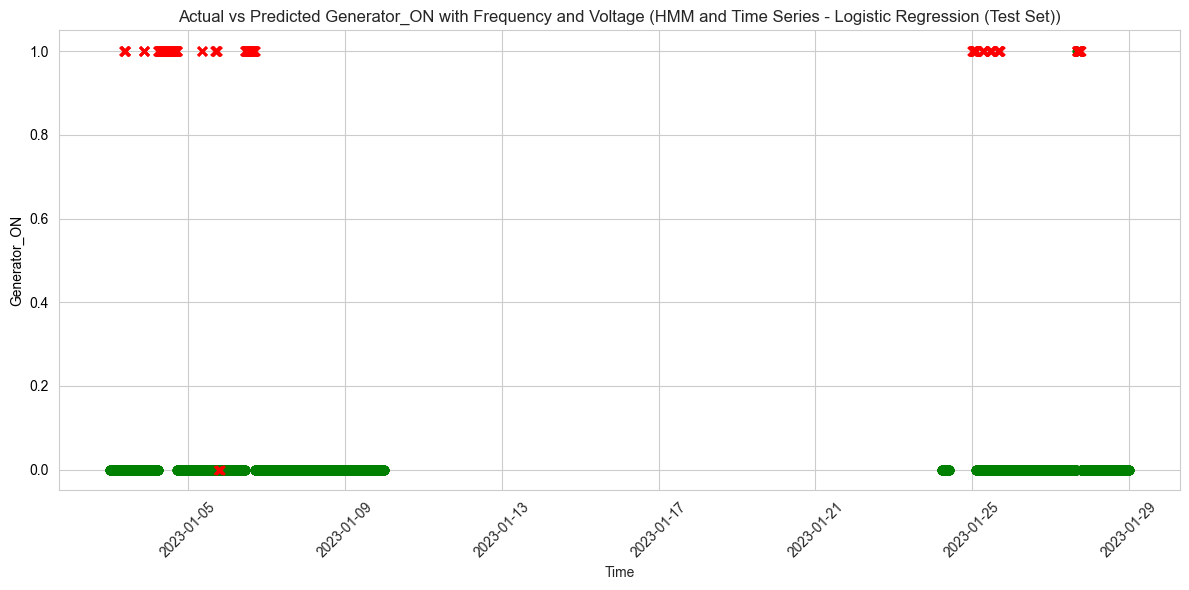

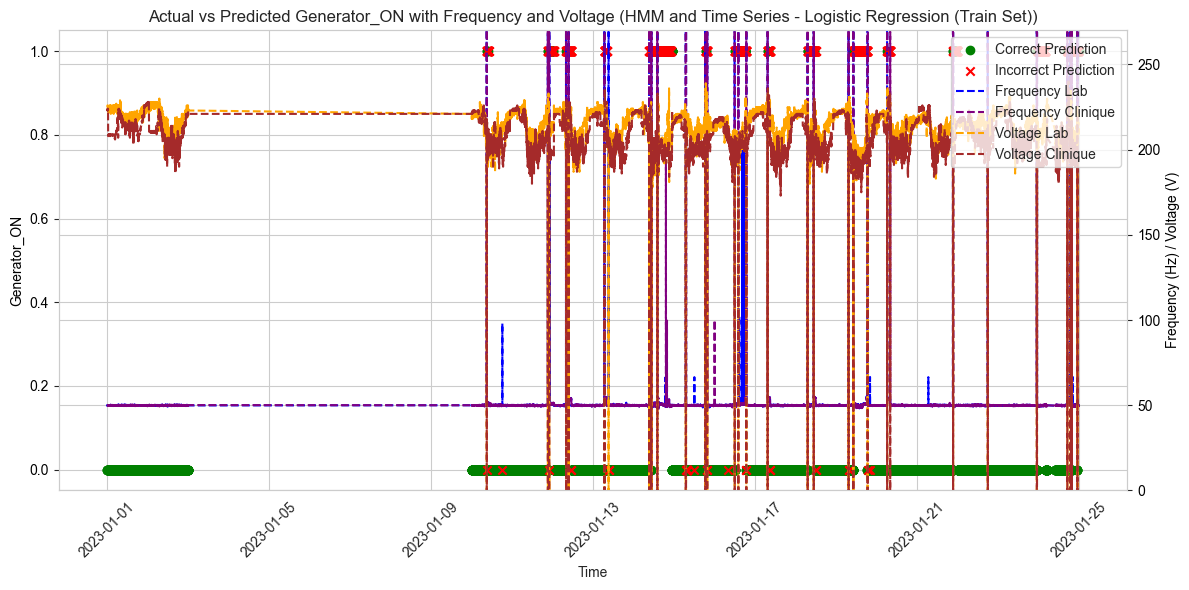

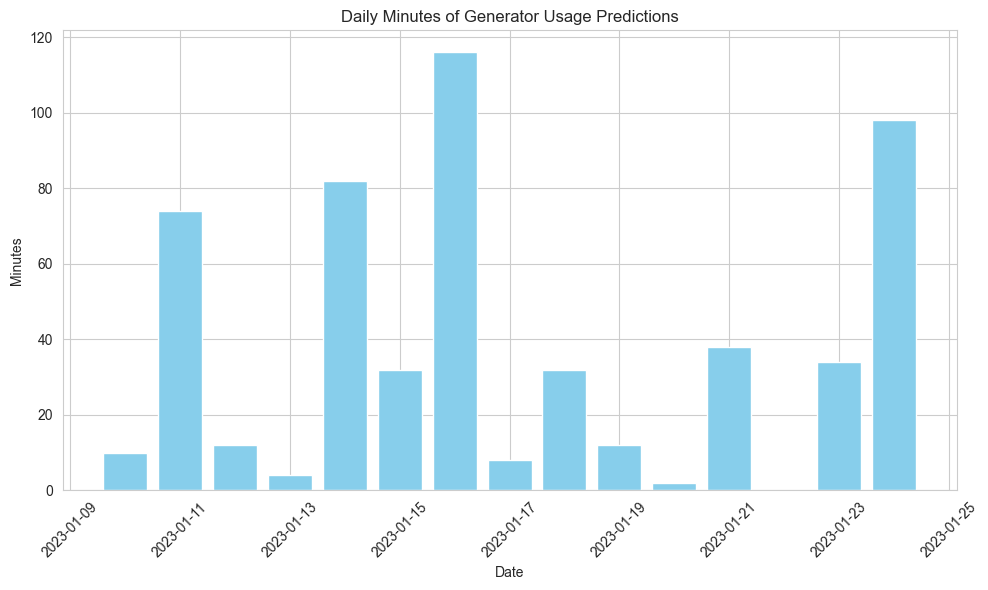

,Date,Count,Minutes,Hours
0,2023-01-10,5,10,0.166667
1,2023-01-11,37,74,1.233333
2,2023-01-12,6,12,0.200000
3,2023-01-13,2,4,0.066667
4,2023-01-14,41,82,1.366667
5,2023-01-15,16,32,0.533333
6,2023-01-16,58,116,1.933333
7,2023-01-17,4,8,0.133333
8,2023-01-18,16,32,0.533333
9,2023-01-19,6,12,0.200000


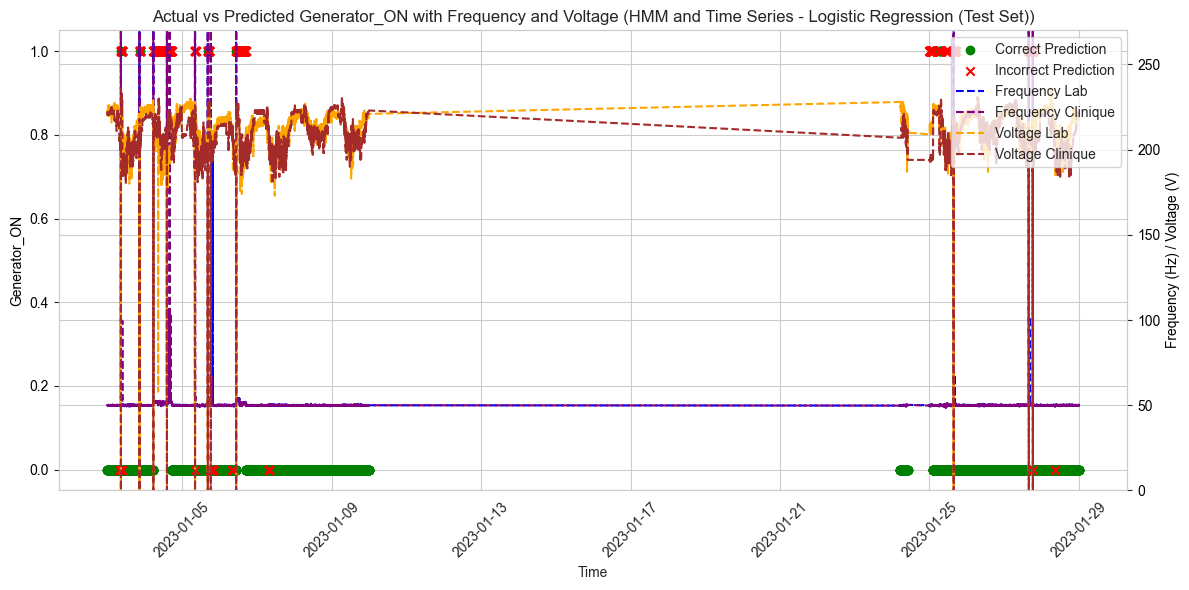

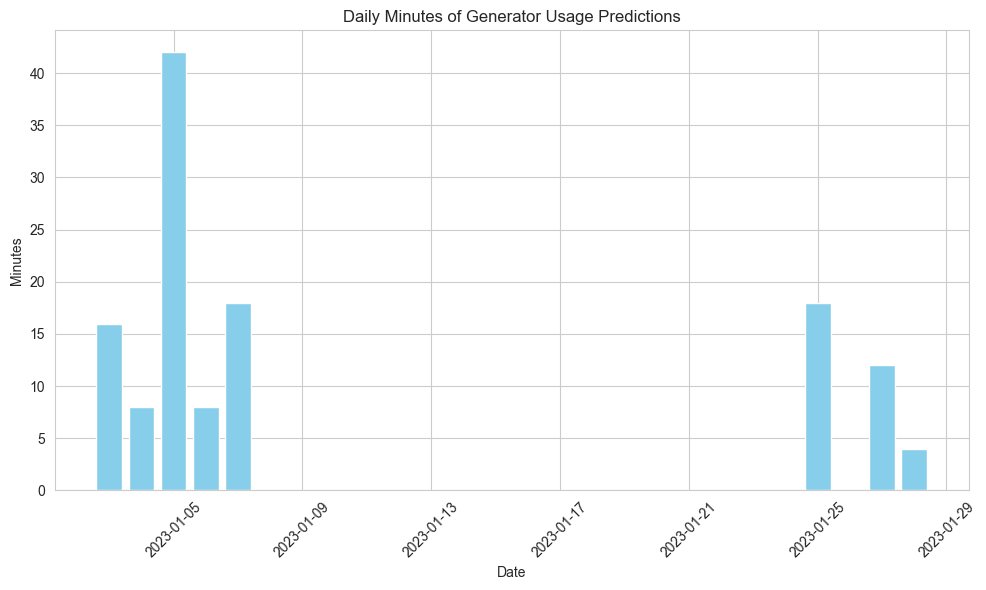

,Date,Count,Minutes,Hours
0,2023-01-03,8,16,0.266667
1,2023-01-04,4,8,0.133333
2,2023-01-05,21,42,0.700000
3,2023-01-06,4,8,0.133333
4,2023-01-07,9,18,0.300000
5,2023-01-25,9,18,0.300000
6,2023-01-27,6,12,0.200000
7,2023-01-28,2,4,0.066667


In [164]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="HMM and Time Series - Logistic Regression (Train Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="HMM and Time Series - Logistic Regression (Test Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_lg, model_name="HMM and Time Series - Logistic Regression (Train Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_lg_daily_count = plot_true_predictions_histogram(train_data_ts_lg)
display(train_data_ts_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_lg, model_name="HMM and Time Series - Logistic Regression (Test Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_lg_daily_count = plot_true_predictions_histogram(test_data_ts_lg)
display(test_data_ts_lg_daily_count)


#### 4.3.2. Adding the Correlation functions (HMM)  - Random Forrest

Top 20 features sorted by importance:


,Feature,Importance
57,HMM_State_Frequency AEBA416D (Hgr Katwa - Cabi...,0.143629
59,HMM_State_Frequency AEBA416D (Hgr Katwa - Cabi...,0.127733
55,HMM_State_Frequency 1C712FB8 (Hgr Katwa - Labo)_3,0.104445
52,HMM_State_Frequency 1C712FB8 (Hgr Katwa - Labo)_0,0.093332
0,Frequency 1C712FB8 (Hgr Katwa - Labo),0.081739
1,Frequency AEBA416D (Hgr Katwa - Cabine),0.080761
3,Voltage AEBA416D (Hgr Katwa - Cabine),0.055178
2,Voltage 1C712FB8 (Hgr Katwa - Labo),0.038197
9,Freq_delta_clinique,0.023746
8,Freq_delta_lab,0.022366


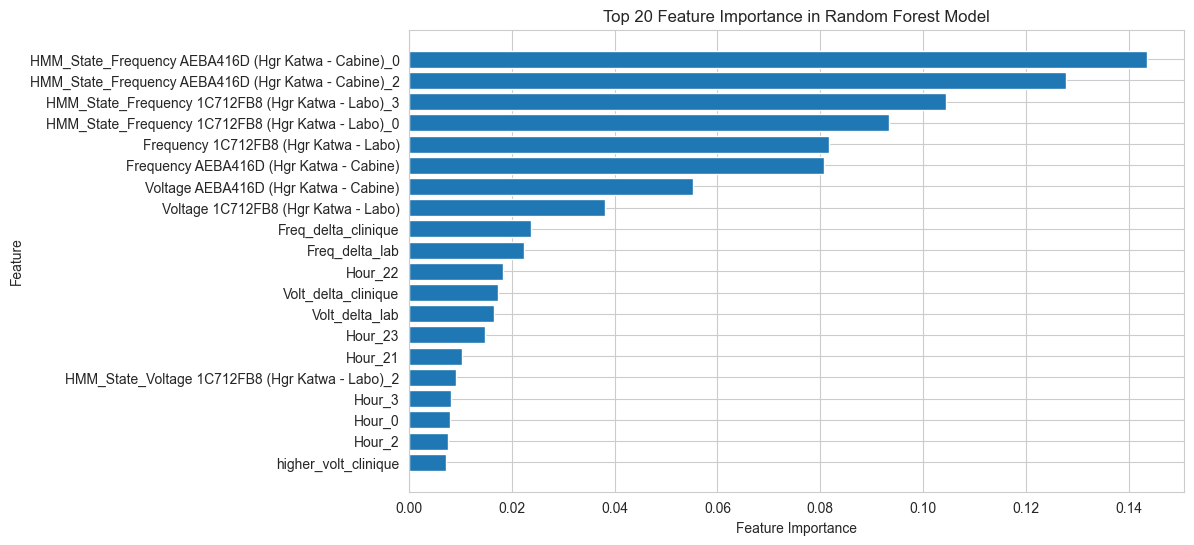

In [165]:
# Step 1: Create copies of the original data
train_data_ts_co_rf = train_data_ts_co.copy()
test_data_ts_co_rf = test_data_ts_co.copy()


# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_co_rf[feature_columns]
y_train = train_data_ts_co_rf['Generator_ON']

X_test = test_data_ts_co_rf[feature_columns]
y_test = test_data_ts_co_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_co_rf['prediction'] = clf.predict(X_train)
test_data_ts_co_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 15 most important features
print("Top 20 features sorted by importance:")
display(top_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

Evaluating the train and test set

Train Set Evaluation:
Accuracy: 0.999917328042328
Confusion Matrix:
[[10322     0]
 [    1  1773]]
Precision: 1.0
Recall: 0.9994363021420518
Train data prediction distribution:
prediction
False    10323
True      1773
Name: count, dtype: int64
Test Set Evaluation:
Accuracy: 0.9756944444444444
Confusion Matrix:
[[7095  100]
 [  96  773]]
Precision: 0.8854524627720504
Recall: 0.8895281933256617
Test data prediction distribution:
prediction
False    7191
True      873
Name: count, dtype: int64


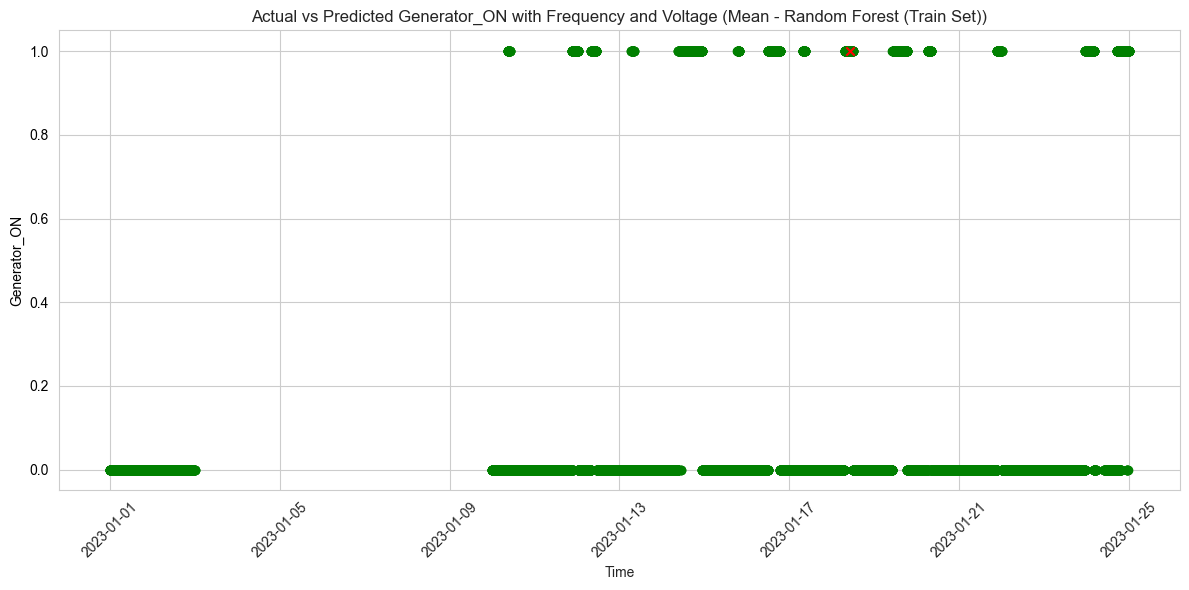

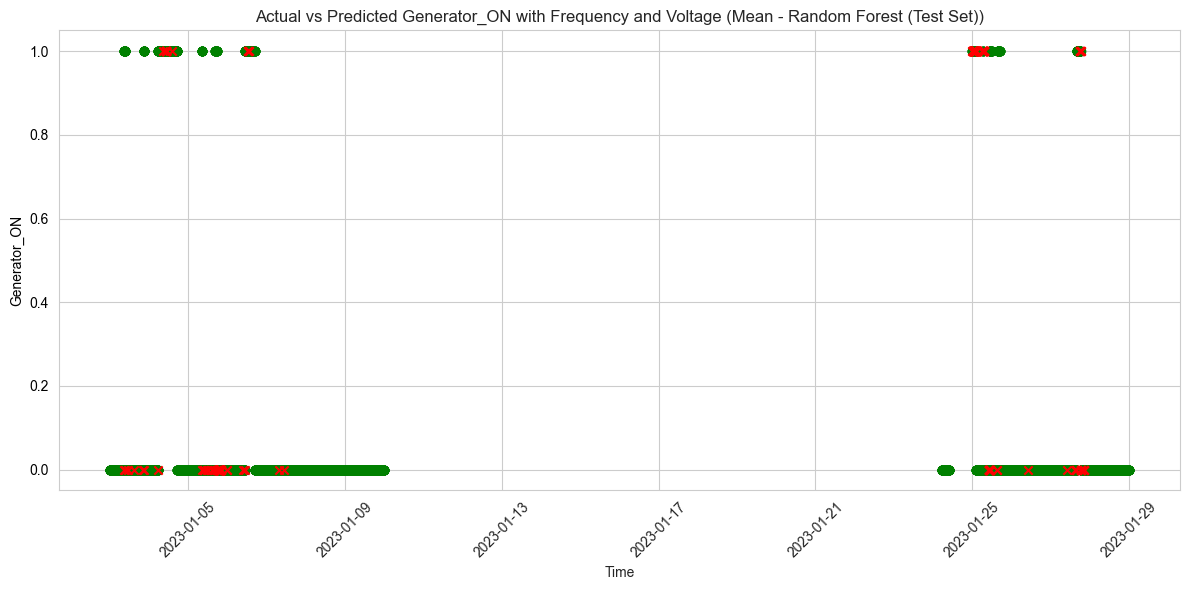

In [166]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_co_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_co_rf['prediction'].value_counts())
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_co_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_co_rf['prediction'].value_counts())

# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False,
                            include_frequency=False)
plot_predictions_vs_actuals(test_data_ts_co_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False,
                            include_frequency=False)

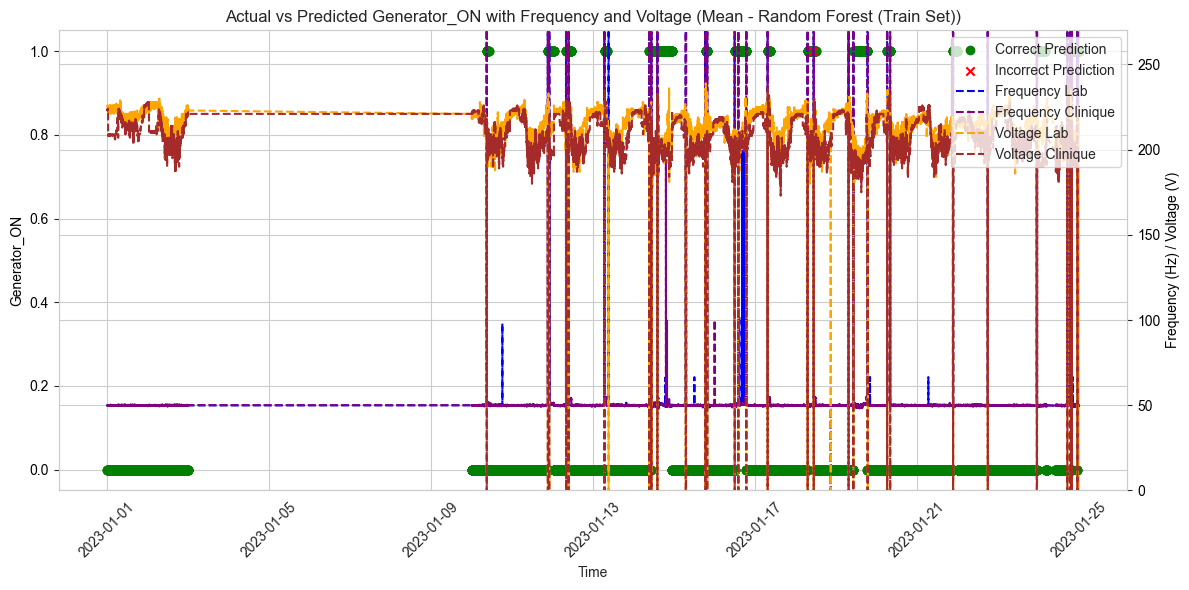

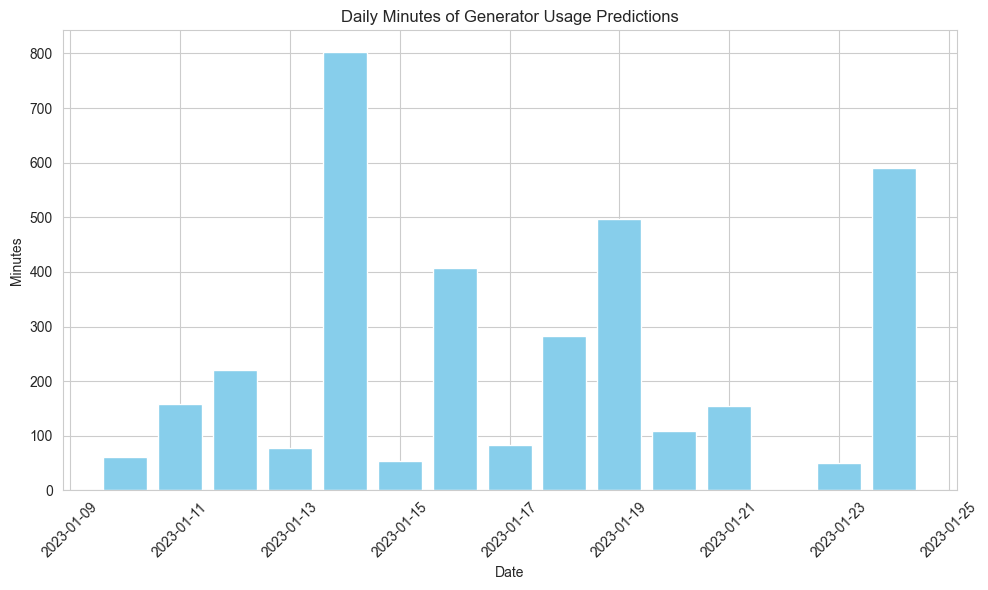

,Date,Count,Minutes,Hours
0,2023-01-10,31,62,1.033333
1,2023-01-11,79,158,2.633333
2,2023-01-12,110,220,3.666667
3,2023-01-13,39,78,1.300000
4,2023-01-14,401,802,13.366667
5,2023-01-15,27,54,0.900000
6,2023-01-16,204,408,6.800000
7,2023-01-17,42,84,1.400000
8,2023-01-18,141,282,4.700000
9,2023-01-19,248,496,8.266667


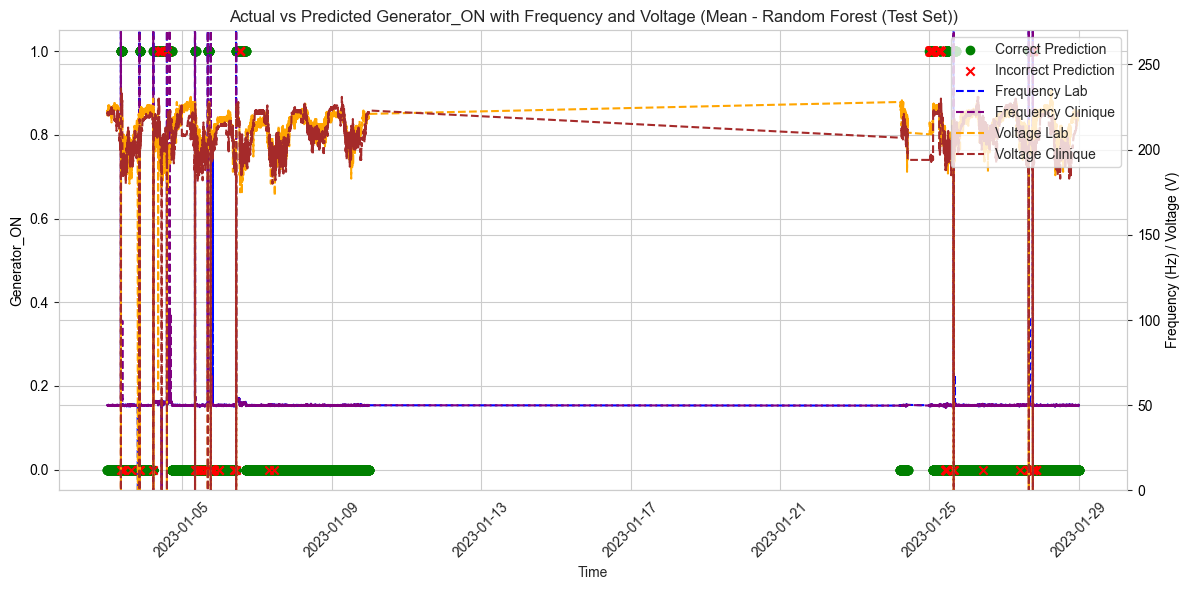

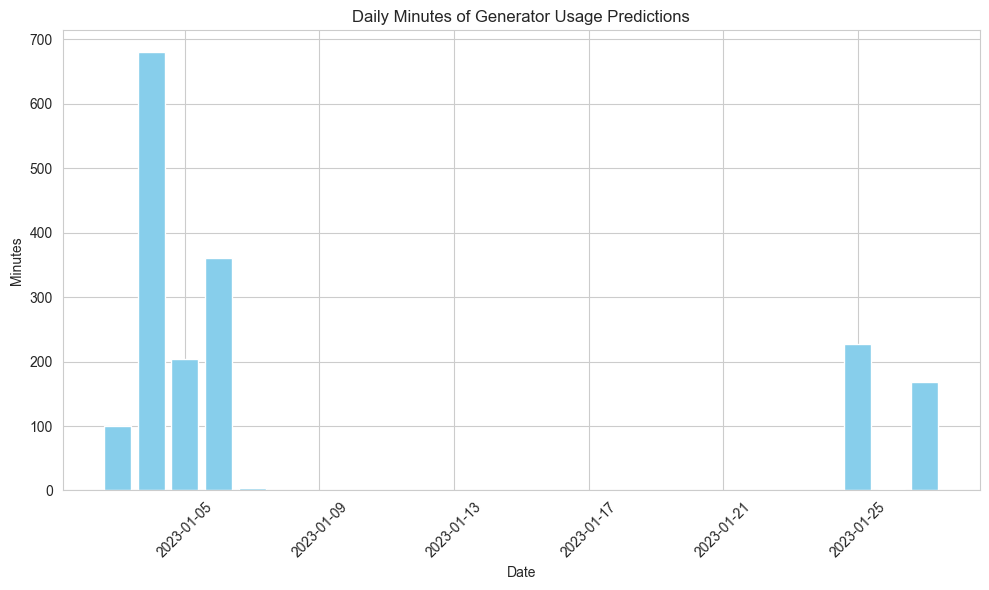

,Date,Count,Minutes,Hours
0,2023-01-03,50,100,1.666667
1,2023-01-04,340,680,11.333333
2,2023-01-05,102,204,3.400000
3,2023-01-06,180,360,6.000000
4,2023-01-07,2,4,0.066667
5,2023-01-25,114,228,3.800000
6,2023-01-26,1,2,0.033333
7,2023-01-27,84,168,2.800000


##### PREDICTION RESULT #####
Actual Minutes: 1774 minutes, or 29.57 hours within 201.60 hours
Predicted Minutes: 1773 minutes, or 29.55 hours within 201.60 hours
Actual Minutes: 869 minutes, or 14.48 hours within 134.40 hours
Predicted Minutes: 873 minutes, or 14.55 hours within 134.40 hours


In [167]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
train_data_ts_co_rf_daily_count = plot_true_predictions_histogram(train_data_ts_co_rf)
display(train_data_ts_co_rf_daily_count)

# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_co_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
test_data_ts_co_rf_daily_count = plot_true_predictions_histogram(test_data_ts_co_rf)
display(test_data_ts_co_rf_daily_count)
train_data_ts_co_rf['Generator_ON'].dtype

print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_rf)
display_generator_statistics(test_data_ts_co_rf)

#### 4.3.3. Adding the Correlation functions (HMM) - XGBoost

In [168]:
# Step 0: Copy rf data
train_data_ts_co_boost = train_data_ts_co.copy()
test_data_ts_co_boost = test_data_ts_co.copy()

# Step 1: Use the same data and feature columns (with copy to avoid SettingWithCopyWarning)
X_train = train_data_ts_co_boost[feature_columns].copy()
y_train = train_data_ts_co_boost['Generator_ON']

X_test = test_data_ts_co_boost[feature_columns].copy()
y_test = test_data_ts_co_boost['Generator_ON']

# Convert specific columns to numeric
cols_to_convert = [
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_train[cols_to_convert] = X_train[cols_to_convert].apply(pd.to_numeric, errors='coerce')
X_test[cols_to_convert] = X_test[cols_to_convert].apply(pd.to_numeric, errors='coerce')

#### This section is for XGBoost parameter search using cross validation

In [169]:
'''
# Step 2: Train an XGBoost Classifier
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',  # Adjust based on your metric
    cv=3,               # Cross-validation splits
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


# Step 3: Make Predictions on the train and test sets
train_data_ts_co_boost['prediction'] = xgb_clf.predict(X_train)
test_data_ts_co_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()
'''

'\n# Step 2: Train an XGBoost Classifier\nparam_grid = {\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'n_estimators\': [100, 300, 500],\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'colsample_bytree\': [0.6, 0.8, 1.0],\n    \'gamma\': [0, 1, 5],\n    \'reg_alpha\': [0, 0.1, 1],\n    \'reg_lambda\': [1, 10, 100]\n}\n\ngrid_search = GridSearchCV(\n    estimator=XGBClassifier(random_state=42),\n    param_grid=param_grid,\n    scoring=\'roc_auc\',  # Adjust based on your metric\n    cv=3,               # Cross-validation splits\n    verbose=2\n)\n\ngrid_search.fit(X_train, y_train)\n\nprint("Best parameters:", grid_search.best_params_)\n\n\n# Step 3: Make Predictions on the train and test sets\ntrain_data_ts_co_boost[\'prediction\'] = xgb_clf.predict(X_train)\ntest_data_ts_co_boost[\'prediction\'] = xgb_clf.predict(X_test)\n\n# Step 4: Evaluate Feature Importances\nimportances = xgb_clf.feature_importances_\n\n# Create a DataFrame for better visualization\nf

In [170]:
# Use the best parameters from GridSearchCV - Saved so no need to re run the parameters. Only re run if we have additional features or different training data 

best_params = {
    'colsample_bytree': 0.6,
    'gamma': 0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 300,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'subsample': 1.0
}


# Initialize the model with the best parameters
final_model = XGBClassifier(
    random_state=42,
    **best_params
)

# Fit the model on the entire training data
final_model.fit(X_train, y_train)

# Make predictions on the test set
train_data_ts_co_boost['prediction'] = final_model.predict(X_train)
test_data_ts_co_boost['prediction'] = final_model.predict(X_test)

# Evaluate the model on the test set
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Classification report
print("Classification Report:")
print(classification_report(y_test, test_data_ts_co_boost['prediction']))

# AUC-ROC score
print("AUC-ROC Score:")
y_test_proba = final_model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_test_proba))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_data_ts_co_boost['prediction']))

# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_ts_co_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_ts_co_boost['prediction'].value_counts())
# Evaluate on the test set
print("\nTest Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_ts_co_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(test_data_ts_co_boost['prediction'].value_counts())

Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.98      0.98      7195
        True       0.84      0.89      0.86       869

    accuracy                           0.97      8064
   macro avg       0.91      0.93      0.92      8064
weighted avg       0.97      0.97      0.97      8064

AUC-ROC Score:
0.9851488735224804
Confusion Matrix:
[[7048  147]
 [  96  773]]
Train Set Evaluation (XGBoost):
Accuracy: 0.9840443121693122
Confusion Matrix:
[[10306    16]
 [  177  1597]]
Precision: 0.9900805951642901
Recall: 0.9002254791431793
Train data prediction distribution (XGBoost):
prediction
0    10483
1     1613
Name: count, dtype: int64

Test Set Evaluation (XGBoost):
Accuracy: 0.9698660714285714
Confusion Matrix:
[[7048  147]
 [  96  773]]
Precision: 0.8402173913043478
Recall: 0.8895281933256617
Test data prediction distribution (XGBoost):
prediction
0    7144
1     920
Name: count, dtype: int64


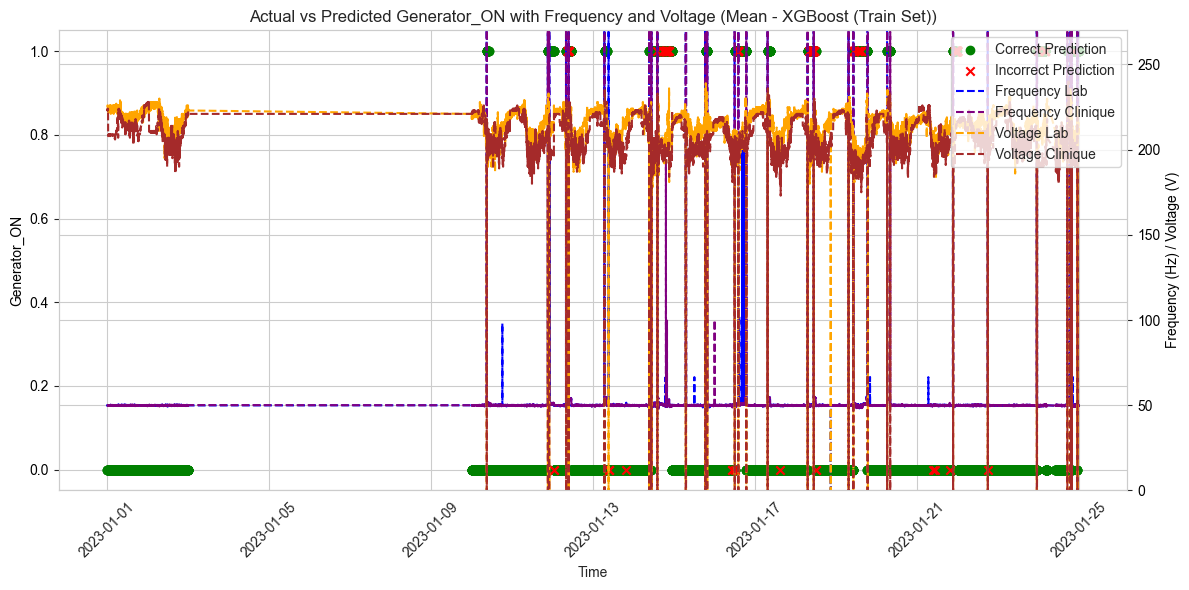

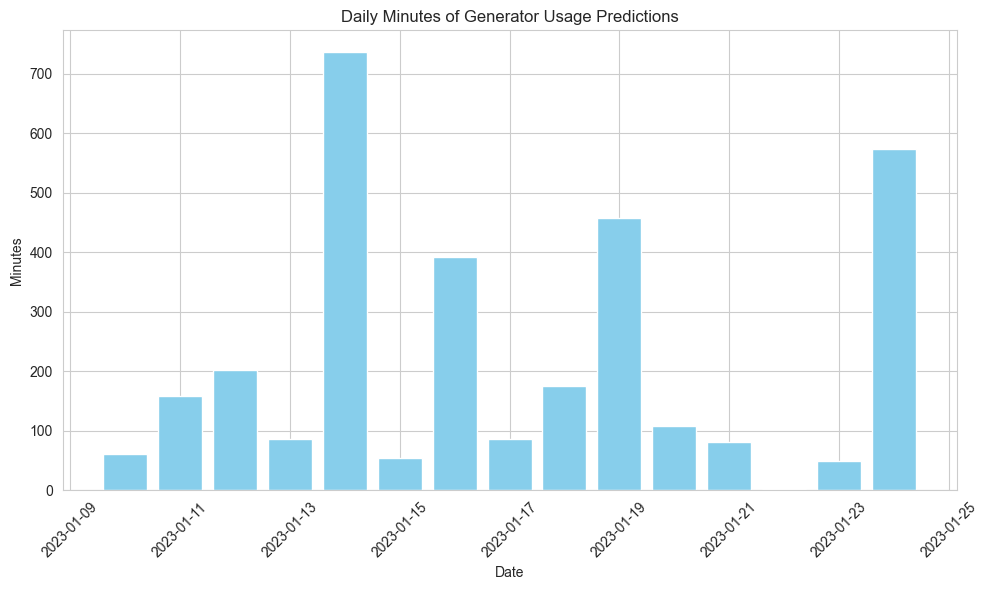

,Date,Count,Minutes,Hours
0,2023-01-10,31,62,1.033333
1,2023-01-11,79,158,2.633333
2,2023-01-12,101,202,3.366667
3,2023-01-13,43,86,1.433333
4,2023-01-14,368,736,12.266667
5,2023-01-15,27,54,0.900000
6,2023-01-16,196,392,6.533333
7,2023-01-17,43,86,1.433333
8,2023-01-18,88,176,2.933333
9,2023-01-19,229,458,7.633333


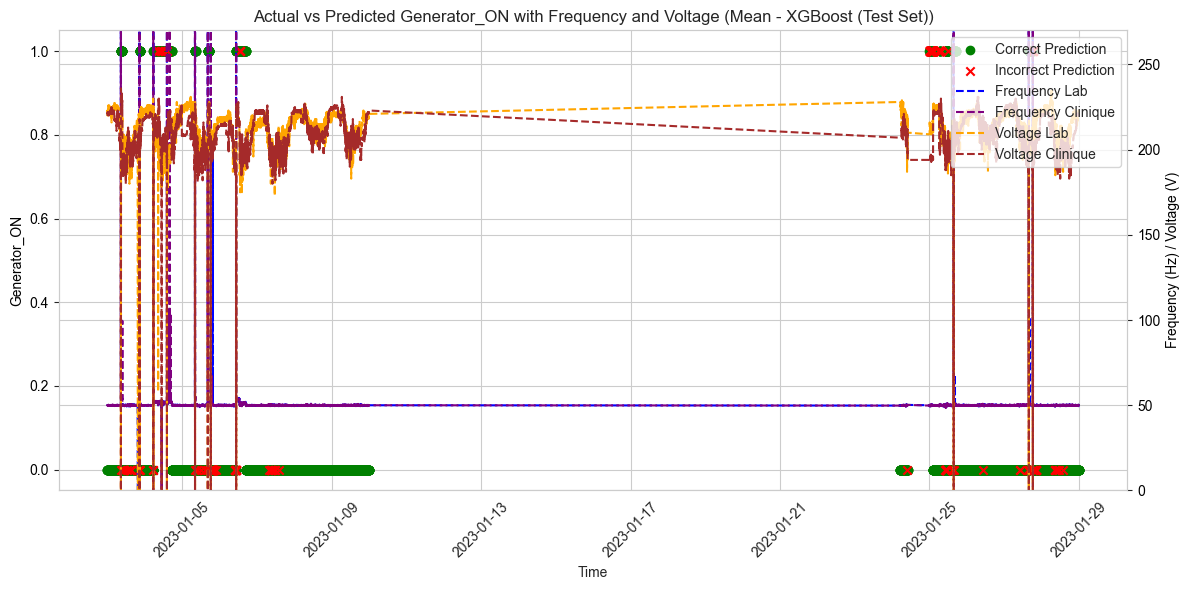

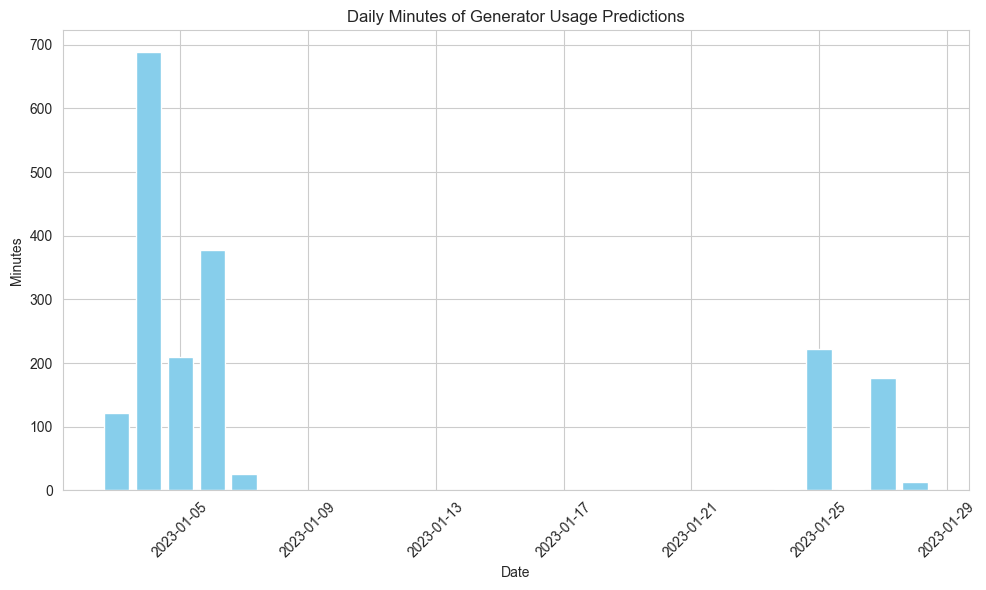

,Date,Count,Minutes,Hours
0,2023-01-03,61,122,2.033333
1,2023-01-04,344,688,11.466667
2,2023-01-05,105,210,3.500000
3,2023-01-06,189,378,6.300000
4,2023-01-07,13,26,0.433333
5,2023-01-24,1,2,0.033333
6,2023-01-25,111,222,3.700000
7,2023-01-26,1,2,0.033333
8,2023-01-27,88,176,2.933333
9,2023-01-28,7,14,0.233333


In [171]:
# For Boosting Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_boost, model_name="Mean - XGBoost (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
train_data_ts_co_boost_daily_count = plot_true_predictions_histogram(train_data_ts_co_boost)
display(train_data_ts_co_boost_daily_count)

# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_co_boost, model_name="Mean - XGBoost (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
test_data_ts_co_boost_daily_count = plot_true_predictions_histogram(test_data_ts_co_boost)
display(test_data_ts_co_boost_daily_count)

In [172]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_boost)
display_generator_statistics(test_data_ts_co_boost)

##### PREDICTION RESULT #####
Actual Minutes: 1774 minutes, or 29.57 hours within 201.60 hours
Predicted Minutes: 1613 minutes, or 26.88 hours within 201.60 hours
Actual Minutes: 869 minutes, or 14.48 hours within 134.40 hours
Predicted Minutes: 920 minutes, or 15.33 hours within 134.40 hours


## 5. Applying the Model with Other Data

Top 15 features sorted by importance:


,Feature,Importance
1,Frequency AEBA416D (Hgr Katwa - Cabine),0.239163
0,Frequency 1C712FB8 (Hgr Katwa - Labo),0.234582
3,Voltage AEBA416D (Hgr Katwa - Cabine),0.092738
2,Voltage 1C712FB8 (Hgr Katwa - Labo),0.079480
9,Freq_delta_clinique,0.042932
8,Freq_delta_lab,0.042390
11,Volt_delta_clinique,0.026318
10,Volt_delta_lab,0.025289
6,higher_volt_lab,0.018703
42,Hour_22,0.018541


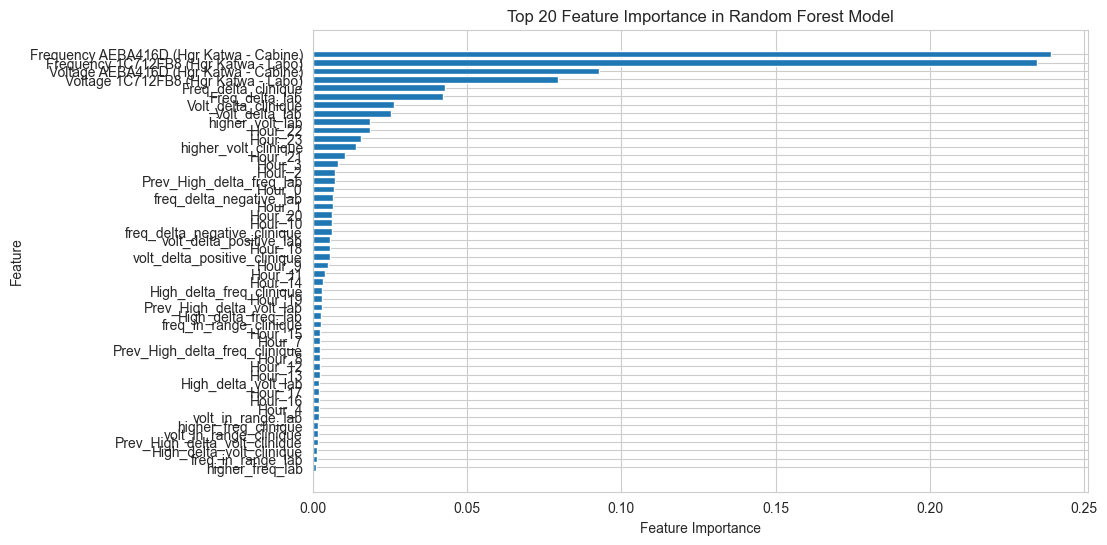

In [173]:
# Final Model use for prediction

# Step 1: Create copies of the original data
train_data_ts_rf = train_data_ts.copy()
test_data_ts_rf = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_rf, test_data_ts_rf = calculate_mean_flags(train_data_ts_rf, test_data_ts_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_rf[feature_columns]
y_train = train_data_ts_rf['Generator_ON']

X_test = test_data_ts_rf[feature_columns]
y_test = test_data_ts_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_rf['prediction'] = clf.predict(X_train)
test_data_ts_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(50)

# Display the top 15 most important features
print("Top 15 features sorted by importance:")
display(top_15_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_15_features['Feature'], top_15_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

#### 5.1. Using 1 Month Data and Check the Prediction Result

In [174]:
# Opening files
file_list = ['Voltage Time Series-data-2024-10-25 13_13_06.csv',  
             'Voltage Time Series-data-2024-10-25 13_13_40.csv', 
             'Voltage Time Series-data-2024-10-25 13_14_12.csv',
             'Voltage Time Series-data-2024-10-25 13_14_37.csv',
             'Voltage Time Series-data-2024-10-25 13_18_07.csv']

# Initialize an empty list to collect DataFrames
data_frames_2 = []

file_path_2 = 'data/0. ChCbNdosho/New 2/'

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path_2 + file)
    data_frames_2.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames_2, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

FileNotFoundError: [Errno 2] No such file or directory: 'data/0. ChCbNdosho/New 2/Voltage Time Series-data-2024-10-25 13_13_06.csv'

In [ ]:
test_data_2

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2, test_data_2_dummy = calculate_mean_flags(data, data, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2, test_data_2_dummy = process_time_series_data(test_data_2, test_data_2, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
test_data_2_daily_count = plot_true_predictions_histogram(test_data_2)
test_data_2_daily_count

#### 5.2. Using 1 Year Data of Year 2023

Loading 1 year data into 1 dataframe:

In [ ]:
# Set the path to the folder containing CSV files
folder_path = 'data/0. ChCbNdosho/2023 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2023 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2023['time'] = pd.to_datetime(data_2023['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2023 = data_2023.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2023

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2023, test_data_2023_dummy = calculate_mean_flags(data_2023, data_2023, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2023, test_data_2023_dummy = process_time_series_data(test_data_2023, test_data_2023, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2023)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2023[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2023['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

##### 5.2.1. Plot Result During Lost Clinique Data (2023)

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2023, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2023-12-01 00:00:00'
finished_date = '2023-12-31 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30
average_daily = filtered_test_data_2_daily_count['Minutes'].sum() / filtered_test_data_2_daily_count.shape[0] 
max_daily = filtered_test_data_2_daily_count['Minutes'].max()
# Find the row with the maximum 'Minutes' value
max_daily_row = filtered_test_data_2_daily_count.loc[filtered_test_data_2_daily_count['Minutes'].idxmax()]
# Extract the 'Date' column from that row
max_date = max_daily_row['Date']


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')
print(f'Average Daily Usage Minutes: {average_daily} minutes, or {average_daily / 60} hours')
print(f'Max minutes of usage {max_daily} minutes or {max_daily / 60} hours. Date: {max_date}')

##### 5.2.2. Plot Result First 10 days of July (2023)

In [ ]:
# Plot predictions based on certain timing choosen
start_date = '2023-02-14 00:00:00'
finished_date = '2023-02-17 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)

# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

#### 5.3. Using Data of Year 2022

Due to data limitations, only Data from 27th May 2022 - 31st December 2022 is available

In [ ]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = 'data/0. ChCbNdosho/2022 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2022 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2022['time'] = pd.to_datetime(data_2022['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2022 = data_2022.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2022


In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2022, test_data_2022_dummy = calculate_mean_flags(data_2022, data_2022, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2022, test_data_2022_dummy = process_time_series_data(test_data_2022, test_data_2022, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2022)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2022[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2022['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2022['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2022) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

##### 5.2.2. Plot Result During Lost Clinique Data (2022)

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2022, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2022-06-20 00:00:00'
finished_date = '2022-06-30 23:59:59'
filtered_test_data_2022 = test_data_2022[(test_data_2022['Time'] >= start_date) & (test_data_2022['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2022,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2022)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2022['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2022) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

#### 5.4. Using Data of Year 2024

In [ ]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = 'data/0. ChCbNdosho/2024 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2024 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2024['time'] = pd.to_datetime(data_2024['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2024 = data_2024.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2024

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2024, test_data_2024_dummy = calculate_mean_flags(data_2024, data_2024, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2024, test_data_2024_dummy = process_time_series_data(test_data_2024, test_data_2024, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2024)

# Define the feature columns
feature_columns = [
    freq_a,
    freq_b,
    volt_a,
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2024[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2024['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2024['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2024) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2024, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2024-10-11 00:00:00'
finished_date = '2024-10-20 23:59:59'
filtered_test_data_2024 = test_data_2024[(test_data_2024['Time'] >= start_date) & (test_data_2024['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2024,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2024)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2024['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2024) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

In [ ]:
## CHECK : 4-11 November

## 6. Summary of Data

#### 6.1. Generator 2022 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 6.2. Generator 2023 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 6.3. Generator 2024 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

## 7. Generator Power Calculation

In [ ]:
# Constant Declaration of Hourly kwh average
kwh_hour = [
    6.747835296, 7.057838155, 8.16854183, 11.30196556, 11.21547191, 9.88189269, 11.22740354, 12.85224141, 14.05086424, 13.96076821,
    13.70200973, 13.46483643, 13.25040271, 12.23739568, 9.853452467, 11.13546578, 11.58039839, 9.594331892, 9.649361468,
    8.320364238, 6.779637969, 6.241952539, 6.125157442, 6.18646468
]

#### 7.1. Generator 2022 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2022['power (kW)'] = test_data_2022.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2022[test_data_2022['prediction']]

In [ ]:
# Year 2022 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 7.2. Generator 2023 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2023['power (kW)'] = test_data_2023.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2023[test_data_2023['prediction']]

In [ ]:
# Year 2023 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 7.3. Generator 2024 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2024['power (kW)'] = test_data_2024.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2024[test_data_2024['prediction']]

In [ ]:
# Year 2024 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

## 8. Generator Emission Calculation

In [ ]:
# Constant Declaration of Emission index

#Assuming Un-Controlled NOx
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

kwh_to_hp_hr = 1.341
lb_to_gr = 453.592

#### 8.1. Generator 2022 Emission

In [ ]:
test_data_2022 = calculate_emissions(test_data_2022)

test_data_2022[test_data_2022['prediction']]

In [ ]:
generator_emission_summary(test_data_2022)

#### 8.2. Generator 2023 Emission

In [ ]:
test_data_2023 = calculate_emissions(test_data_2023)

test_data_2023[test_data_2023['prediction']]

In [ ]:
generator_emission_summary(test_data_2023)

#### 8.3. Generator 2024 Emission

In [ ]:
test_data_2024 = calculate_emissions(test_data_2024)

test_data_2024[test_data_2024['prediction']]

In [ ]:
generator_emission_summary(test_data_2024)

## 9. Generator Output Emissions File

In [ ]:
file_name = ["data_2022.csv", "data_2023.csv", "data_2024.csv"]
years = [2022, 2023, 2024]
columns = ['Time','prediction','power (kW)','NOx Emission (g)','CO Emission (g)','SOx Emission (g)','CO2 Emission (g)','PM Emission (g)', 'Date', 'Month']

test_data_2024[columns].to_csv('results/data_2024.csv', index = False)
test_data_2023[columns].to_csv('results/data_2023.csv', index = False)
test_data_2022[columns].to_csv('results/data_2022.csv', index = False)